Data loader code

In [5]:
# ============================================
# Cell L1: imports and config
# ============================================
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

DATA_ROOT = "hand_dummy/data"

VIDEO_INPUT_ENABLED = False
BODY_POSE_INPUT_ENABLED = True
HAND_POSE_INPUT_ENABLED = True

LABELS = ["go", "stop", "left", "right", "null"]

# Use None to keep all 17 body landmarks
BODY_LANDMARK_USED = [5, 6,7,  8,9, 10,11,12]

BATCH_SIZE = 16
NUM_WORKERS = 0
VIDEO_SIZE = (112, 112)   # (W, H)
VIDEO_NORMALIZE = True

# --------------------------------------------
# Fixed padded lengths for each modality
# --------------------------------------------
VIDEO_PAD_LENGTH = 64   # final video shape: [64, C, H, W]
BODY_PAD_LENGTH = 64    # final body shape:  [64, K, 2]
HAND_PAD_LENGTH = 64    # final hand shape:  [64, 21, 2]

# If True, samples longer than target length are truncated
TRUNCATE_IF_LONGER = True

# Screening
REQUIRE_ALL_THREE_COMPONENTS = True
VERBOSE_SCREENING = True

In [6]:
# ============================================
# Cell L2: helpers
# ============================================
LABEL_TO_IDX = {name: i for i, name in enumerate(LABELS)}
IDX_TO_LABEL = {i: name for name, i in LABEL_TO_IDX.items()}


def apply_body_landmark_selection(body_np, landmark_indices=None):
    if landmark_indices is None:
        return body_np
    return body_np[:, landmark_indices, :]


def check_video_readable(video_path):
    if not os.path.isfile(video_path):
        return False, "video file missing"

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False, "video cannot be opened"

    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        return False, "video has no readable frames"

    return True, None


def check_npy_shape(npy_path, expected_num_landmarks, name):
    """
    expected shape: [N, expected_num_landmarks, 2]
    """
    if not os.path.isfile(npy_path):
        return False, None, f"{name} file missing"

    try:
        arr = np.load(npy_path)
    except Exception as e:
        return False, None, f"{name} npy load failed: {e}"

    if arr.ndim != 3:
        return False, arr.shape, f"{name} ndim should be 3, got {arr.ndim}"

    if arr.shape[1] != expected_num_landmarks:
        return False, arr.shape, f"{name} landmark count should be {expected_num_landmarks}, got {arr.shape[1]}"

    if arr.shape[2] != 2:
        return False, arr.shape, f"{name} last dim should be 2, got {arr.shape[2]}"

    if arr.shape[0] <= 0:
        return False, arr.shape, f"{name} has zero length"

    return True, arr.shape, None


def load_video_cv2(video_path, target_size=(224, 224), normalize=True):
    """
    Returns video tensor of shape [T, C, H, W]
    """
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, target_size)
        frame = torch.from_numpy(frame).float()  # [H, W, C]

        if normalize:
            frame = frame / 255.0

        frame = frame.permute(2, 0, 1)  # [C, H, W]
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"Could not read frames from video: {video_path}")

    return torch.stack(frames, dim=0)  # [T, C, H, W]


def pad_or_truncate_tensor(x, target_len):
    """
    x shape: [T, ...]
    output shape: [target_len, ...]
    """
    cur_len = x.shape[0]

    if cur_len == target_len:
        return x

    if cur_len > target_len:
        return x[:target_len] if TRUNCATE_IF_LONGER else x

    pad_shape = (target_len - cur_len,) + tuple(x.shape[1:])
    pad_tensor = torch.zeros(pad_shape, dtype=x.dtype)
    return torch.cat([x, pad_tensor], dim=0)

In [7]:
# ============================================
# Cell L3: dataset with screening + fixed-length padding
# ============================================
class GestureEpisodeDataset(Dataset):
    def __init__(
        self,
        data_root,
        labels,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        body_landmark_used=None,
        video_size=(224, 224),
        video_normalize=True,
        video_pad_length=None,
        body_pad_length=None,
        hand_pad_length=None,
        require_all_three_components=True,
        verbose_screening=True,
    ):
        self.data_root = data_root
        self.labels = labels
        self.video_input_enabled = video_input_enabled
        self.body_pose_input_enabled = body_pose_input_enabled
        self.hand_pose_input_enabled = hand_pose_input_enabled
        self.body_landmark_used = body_landmark_used
        self.video_size = video_size
        self.video_normalize = video_normalize
        self.video_pad_length = video_pad_length
        self.body_pad_length = body_pad_length
        self.hand_pad_length = hand_pad_length
        self.require_all_three_components = require_all_three_components
        self.verbose_screening = verbose_screening

        self.label_to_idx = {name: i for i, name in enumerate(labels)}

        if not (self.video_input_enabled or self.body_pose_input_enabled or self.hand_pose_input_enabled):
            raise ValueError("At least one input modality must be enabled.")

        self.samples = self._build_index()

        if len(self.samples) == 0:
            raise ValueError("No valid samples found after screening.")

    def _screen_one_sample(self, body_path, hand_path, video_path):
        reasons = []

        if self.require_all_three_components:
            if not os.path.isfile(body_path):
                reasons.append("missing body file")
            if not os.path.isfile(hand_path):
                reasons.append("missing hand file")
            if not os.path.isfile(video_path):
                reasons.append("missing video file")
            if reasons:
                return False, reasons
        else:
            if self.body_pose_input_enabled and not os.path.isfile(body_path):
                reasons.append("missing body file")
            if self.hand_pose_input_enabled and not os.path.isfile(hand_path):
                reasons.append("missing hand file")
            if self.video_input_enabled and not os.path.isfile(video_path):
                reasons.append("missing video file")
            if reasons:
                return False, reasons

        check_body = self.require_all_three_components or self.body_pose_input_enabled
        check_hand = self.require_all_three_components or self.hand_pose_input_enabled
        check_video = self.require_all_three_components or self.video_input_enabled

        if check_body:
            ok, shape, reason = check_npy_shape(body_path, 17, "body")
            if not ok:
                reasons.append(reason if reason is not None else f"invalid body shape: {shape}")

        if check_hand:
            ok, shape, reason = check_npy_shape(hand_path, 21, "hand")
            if not ok:
                reasons.append(reason if reason is not None else f"invalid hand shape: {shape}")

        if check_video:
            ok, reason = check_video_readable(video_path)
            if not ok:
                reasons.append(reason)

        if reasons:
            return False, reasons

        return True, None

    def _build_index(self):
        samples = []
        skipped = []

        for class_name in self.labels:
            class_dir = os.path.join(self.data_root, class_name)
            if not os.path.isdir(class_dir):
                skipped.append((class_name, "class folder missing"))
                continue

            all_session_prefixes = set()
            for path in glob.glob(os.path.join(class_dir, "session_*_body.npy")):
                all_session_prefixes.add(os.path.basename(path).replace("_body.npy", ""))
            for path in glob.glob(os.path.join(class_dir, "session_*_hand.npy")):
                all_session_prefixes.add(os.path.basename(path).replace("_hand.npy", ""))
            for path in glob.glob(os.path.join(class_dir, "session_*.mp4")):
                all_session_prefixes.add(os.path.basename(path).replace(".mp4", ""))

            for base in sorted(all_session_prefixes):
                body_path = os.path.join(class_dir, f"{base}_body.npy")
                hand_path = os.path.join(class_dir, f"{base}_hand.npy")
                video_path = os.path.join(class_dir, f"{base}.mp4")

                ok, reasons = self._screen_one_sample(body_path, hand_path, video_path)

                if not ok:
                    skipped.append((f"{class_name}/{base}", "; ".join(reasons)))
                    continue

                samples.append({
                    "label_name": class_name,
                    "label_idx": self.label_to_idx[class_name],
                    "body_path": body_path,
                    "hand_path": hand_path,
                    "video_path": video_path,
                    "session_id": base,
                })

        if self.verbose_screening:
            print(f"Valid samples: {len(samples)}")
            print(f"Skipped samples: {len(skipped)}")
            if len(skipped) > 0:
                print("\nSome skipped samples:")
                for item, reason in skipped[:30]:
                    print(f"  - {item}: {reason}")
                if len(skipped) > 30:
                    print(f"  ... and {len(skipped) - 30} more")

        self.skipped_samples = skipped
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample_info = self.samples[idx]
        outputs = []

        body_input_shape = None

        if self.video_input_enabled:
            video = load_video_cv2(
                sample_info["video_path"],
                target_size=self.video_size,
                normalize=self.video_normalize,
            )  # [T, C, H, W]

            if self.video_pad_length is not None:
                video = pad_or_truncate_tensor(video, self.video_pad_length)

            outputs.append(video)

        if self.body_pose_input_enabled:
            body = np.load(sample_info["body_path"]).astype(np.float32)  # [T,17,2]
            body = apply_body_landmark_selection(body, self.body_landmark_used)
            body = torch.from_numpy(body)  # [T,K,2]

            if self.body_pad_length is not None:
                body = pad_or_truncate_tensor(body, self.body_pad_length)

            body_input_shape = tuple(body.shape)
            outputs.append(body)

        if self.hand_pose_input_enabled:
            hand = np.load(sample_info["hand_path"]).astype(np.float32)  # [T,21,2]
            hand = torch.from_numpy(hand)

            if self.hand_pad_length is not None:
                hand = pad_or_truncate_tensor(hand, self.hand_pad_length)

            outputs.append(hand)

        if self.body_pose_input_enabled:
            outputs.append(body_input_shape)

        label = torch.tensor(sample_info["label_idx"], dtype=torch.long)
        return tuple(outputs), label, sample_info["session_id"]

In [8]:
# ============================================
# Cell L4: collate fn
# ============================================
def gesture_collate_fn(batch):

    inputs_list = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]
    return inputs_list, labels, session_ids

In [9]:
# ============================================
# Cell L5: create dataset and dataloader
# ============================================
dataset = GestureEpisodeDataset(
    data_root=DATA_ROOT,
    labels=LABELS,
    video_input_enabled=VIDEO_INPUT_ENABLED,
    body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
    hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
    body_landmark_used=BODY_LANDMARK_USED,
    video_size=VIDEO_SIZE,
    video_normalize=VIDEO_NORMALIZE,
    video_pad_length=VIDEO_PAD_LENGTH,
    body_pad_length=BODY_PAD_LENGTH,
    hand_pad_length=HAND_PAD_LENGTH,
    require_all_three_components=REQUIRE_ALL_THREE_COMPONENTS,
    verbose_screening=VERBOSE_SCREENING,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn,
)

print(f"Final usable sample count: {len(dataset)}")

Valid samples: 500
Skipped samples: 14

Some skipped samples:
  - go/session_0015: hand landmark count should be 21, got 0
  - go/session_0016: hand landmark count should be 21, got 0
  - go/session_0017: hand landmark count should be 21, got 0
  - go/session_0042: hand landmark count should be 21, got 0
  - go/session_0043: hand landmark count should be 21, got 0
  - go/session_0068: hand landmark count should be 21, got 0
  - go/session_0069: hand landmark count should be 21, got 0
  - go/session_0070: hand landmark count should be 21, got 0
  - go/session_0072: hand landmark count should be 21, got 0
  - go/session_0073: missing video file
  - left/session_0005: hand landmark count should be 21, got 0
  - left/session_0033: body landmark count should be 17, got 0; hand landmark count should be 21, got 0
  - left/session_0103: hand landmark count should be 21, got 0
  - left/session_0105: hand landmark count should be 21, got 0
Final usable sample count: 500


In [10]:
# ============================================
# Cell L6: inspect one batch
# ============================================
inputs_list, labels, session_ids = next(iter(loader))

print("Batch size:", len(inputs_list))
print("Labels:", labels)
print("Session IDs:", session_ids)

for i, sample_inputs in enumerate(inputs_list):
    print(f"\n--- Sample {i} ---")
    for j, x in enumerate(sample_inputs):
        if torch.is_tensor(x):
            print(f"item {j}: tensor shape = {tuple(x.shape)}")
        else:
            print(f"item {j}: {x}")

Batch size: 16
Labels: tensor([2, 2, 2, 0, 1, 1, 2, 3, 3, 2, 2, 4, 3, 1, 3, 0])
Session IDs: ['session_0039', 'session_0087', 'session_0042', 'session_0004', 'session_0087', 'session_0073', 'session_0031', 'session_0069', 'session_0101', 'session_0060', 'session_0071', 'session_0054', 'session_0056', 'session_0071', 'session_0092', 'session_0003']

--- Sample 0 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 1 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 2 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 3 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 4 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 5 ---
item 0: tensor shape = (64, 8, 2)
item 1: tensor shape = (64, 21, 2)
item 2: (64, 8, 2)

--- Sample 6 

In [11]:
# ============================================
# Optional Cell L7: stacked collate fn
# ============================================
def gesture_collate_fn_stacked(batch):
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]

    sample0 = batch[0][0]
    num_items = len(sample0)

    collated_inputs = []

    for item_idx in range(num_items):
        values = [sample[0][item_idx] for sample in batch]

        if torch.is_tensor(values[0]):
            collated_inputs.append(torch.stack(values, dim=0))
        else:
            collated_inputs.append(values)

    return tuple(collated_inputs), labels, session_ids

In [12]:
# ============================================
# Cell L8: train / val / test split
# ============================================
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset


# -------------------------
# Split ratios
# -------------------------
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42
STRATIFY_SPLIT = True

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8


def make_train_val_test_subsets(
    dataset,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
    stratify_split=True,
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8

    indices = list(range(len(dataset)))
    labels = [dataset.samples[i]["label_idx"] for i in indices]

    stratify_labels = labels if stratify_split else None

    # First split: train vs temp
    train_indices, temp_indices = train_test_split(
        indices,
        test_size=(1.0 - train_ratio),
        random_state=random_seed,
        stratify=stratify_labels,
    )

    # Second split: val vs test from temp
    temp_labels = [dataset.samples[i]["label_idx"] for i in temp_indices]
    temp_stratify = temp_labels if stratify_split else None

    val_portion_of_temp = val_ratio / (val_ratio + test_ratio)

    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=(1.0 - val_portion_of_temp),
        random_state=random_seed,
        stratify=temp_stratify,
    )

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)

    return train_subset, val_subset, test_subset, train_indices, val_indices, test_indices


def summarize_subset(subset, dataset, name="subset"):
    counts = {}
    for idx in subset.indices:
        label_name = dataset.samples[idx]["label_name"]
        counts[label_name] = counts.get(label_name, 0) + 1

    print(f"{name}: {len(subset)} samples")
    for label in LABELS:
        print(f"  {label}: {counts.get(label, 0)}")


train_dataset, val_dataset, test_dataset, train_idx, val_idx, test_idx = make_train_val_test_subsets(
    dataset=dataset,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_seed=RANDOM_SEED,
    stratify_split=STRATIFY_SPLIT,
)

summarize_subset(train_dataset, dataset, "train")
summarize_subset(val_dataset, dataset, "val")
summarize_subset(test_dataset, dataset, "test")

train: 349 samples
  go: 64
  stop: 70
  left: 73
  right: 71
  null: 71
val: 75 samples
  go: 14
  stop: 15
  left: 16
  right: 15
  null: 15
test: 76 samples
  go: 13
  stop: 16
  left: 16
  right: 16
  null: 15


In [13]:
# ============================================
# Cell L9: dataloaders for train / val / test
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,   # or gesture_collate_fn
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 22
val batches: 5
test batches: 5


In [14]:
# ============================================
# Cell L10: inspect one batch from each split
# ============================================
train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))
test_batch = next(iter(test_loader))

print("Train batch loaded")
print("Val batch loaded")
print("Test batch loaded")

Train batch loaded
Val batch loaded
Test batch loaded


Now actual training

In [15]:
# ============================================
# Cell T1: training config
# ============================================
import os
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ------------------------------------------------
# Model choice
# ------------------------------------------------
MODEL_TYPE = "CNN"   # "LSTM" or "CNN"

# ------------------------------------------------
# Training hyperparameters
# ------------------------------------------------
NUM_CLASSES = len(LABELS)
EPOCHS = 400
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# ------------------------------------------------
# Early fusion feature dimensions
# ------------------------------------------------
VIDEO_FEATURE_DIM = 64

USE_BODY_MLP = False
BODY_FEATURE_DIM = 32

USE_HAND_MLP = False
HAND_FEATURE_DIM = 32

# ------------------------------------------------
# LSTM settings
# ------------------------------------------------
LSTM_HIDDEN_DIM = 128
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.2
LSTM_BIDIRECTIONAL = False

# ------------------------------------------------
# CNN temporal model settings
# ------------------------------------------------
CNN_HIDDEN_DIM = 128
CNN_DROPOUT = 0.2

# ------------------------------------------------
# General classifier settings
# ------------------------------------------------
CLASSIFIER_HIDDEN_DIM = 32
DROPOUT = 0.3

# ------------------------------------------------
# Early Stopping
# ------------------------------------------------
EARLY_STOPPING_PATIENCE = 10   # stop if no improvement for this many epochs
EARLY_STOPPING_MIN_DELTA = 1e-4  # minimum val loss improvement to count

# ------------------------------------------------
# Optimization / scheduling
# ------------------------------------------------
USE_CLASS_WEIGHTS = False
USE_LR_SCHEDULER = True

# ------------------------------------------------
# Saving
# ------------------------------------------------
SAVE_DIR = "./gesture_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, f"best_{MODEL_TYPE.lower()}_early_fusion.pt")



DEVICE: cuda


In [16]:
# ============================================
# Cell T2: stacked collate function
# ============================================
def gesture_collate_fn_stacked(batch):
    """
    Returns:
        inputs_tuple, labels, session_ids

    inputs_tuple content depends on enabled modalities:
    - all enabled: (video, body, hand, body_input_shape_list)
    - body + hand: (body, hand, body_input_shape_list)
    - etc.

    Tensor items are stacked.
    Non-tensor items are returned as list.
    """
    labels = torch.stack([item[1] for item in batch], dim=0)
    session_ids = [item[2] for item in batch]

    sample0 = batch[0][0]
    num_items = len(sample0)

    collated_inputs = []
    for item_idx in range(num_items):
        values = [sample[0][item_idx] for sample in batch]

        if torch.is_tensor(values[0]):
            collated_inputs.append(torch.stack(values, dim=0))
        else:
            collated_inputs.append(values)

    return tuple(collated_inputs), labels, session_ids

In [17]:
# ============================================
# Cell T3: rebuild train / val / test loaders
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))
print("test batches:", len(test_loader))

train batches: 22
val batches: 5
test batches: 5


In [18]:
# ============================================
# Cell T4: multimodal parsing helpers
# ============================================
def unpack_batch_inputs(inputs_tuple):
    """
    Parse the variable-format tuple returned by dataset/collate.

    Returns a dict with keys:
        video: tensor or None
        body: tensor or None
        hand: tensor or None
        body_input_shape: list or None
    """
    result = {
        "video": None,
        "body": None,
        "hand": None,
        "body_input_shape": None,
    }

    idx = 0

    if VIDEO_INPUT_ENABLED:
        result["video"] = inputs_tuple[idx]
        idx += 1

    if BODY_POSE_INPUT_ENABLED:
        result["body"] = inputs_tuple[idx]
        idx += 1

    if HAND_POSE_INPUT_ENABLED:
        result["hand"] = inputs_tuple[idx]
        idx += 1

    if BODY_POSE_INPUT_ENABLED:
        result["body_input_shape"] = inputs_tuple[idx]
        idx += 1

    return result


def move_batch_to_device(batch_dict, device):
    for key in ["video", "body", "hand"]:
        if batch_dict[key] is not None:
            batch_dict[key] = batch_dict[key].to(device)
    return batch_dict

In [19]:
# ============================================
# Cell T5: frame CNN encoder for video
# ============================================
class SmallFrameCNN(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.proj = nn.Linear(64, feature_dim)

    def forward(self, x):
        """
        x: [N, C, H, W]
        returns: [N, feature_dim]
        """
        x = self.features(x)   # [N, 64, 1, 1]
        x = x.flatten(1)       # [N, 64]
        x = self.proj(x)       # [N, feature_dim]
        return x


class VideoEncoder(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64):
        super().__init__()
        self.frame_cnn = SmallFrameCNN(in_channels=in_channels, feature_dim=feature_dim)

    def forward(self, video):
        """
        video: [B, T, C, H, W]
        returns: [B, T, feature_dim]
        """
        B, T, C, H, W = video.shape
        x = video.reshape(B * T, C, H, W)
        x = self.frame_cnn(x)
        x = x.reshape(B, T, -1)
        return x

In [20]:
# ============================================
# Cell T6: body and hand encoders
# ============================================
class BodyEncoder(nn.Module):
    def __init__(self, num_body_landmarks, use_mlp=True, feature_dim=32):
        super().__init__()
        self.input_dim = num_body_landmarks * 2
        self.use_mlp = use_mlp

        if use_mlp:
            self.net = nn.Sequential(
                nn.Linear(self.input_dim, feature_dim),
                nn.ReLU(inplace=True),
            )
            self.output_dim = feature_dim
        else:
            self.net = nn.Identity()
            self.output_dim = self.input_dim

    def forward(self, body):
        """
        body: [B, T, K, 2]
        returns: [B, T, D]
        """
        B, T, K, C = body.shape
        x = body.reshape(B, T, K * C)
        x = self.net(x)
        return x


class HandEncoder(nn.Module):
    def __init__(self, num_hand_landmarks=21, use_mlp=True, feature_dim=32):
        super().__init__()
        self.input_dim = num_hand_landmarks * 2
        self.use_mlp = use_mlp

        if use_mlp:
            self.net = nn.Sequential(
                nn.Linear(self.input_dim, feature_dim),
                nn.ReLU(inplace=True),
            )
            self.output_dim = feature_dim
        else:
            self.net = nn.Identity()
            self.output_dim = self.input_dim

    def forward(self, hand):
        """
        hand: [B, T, 21, 2]
        returns: [B, T, D]
        """
        B, T, K, C = hand.shape
        x = hand.reshape(B, T, K * C)
        x = self.net(x)
        return x

In [21]:
# ============================================
# Cell T7: multimodal early fusion encoder
# ============================================
class MultiModalEarlyFusionEncoder(nn.Module):
    def __init__(
        self,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
    ):
        super().__init__()

        self.video_input_enabled = video_input_enabled
        self.body_pose_input_enabled = body_pose_input_enabled
        self.hand_pose_input_enabled = hand_pose_input_enabled

        fused_dim = 0

        if self.video_input_enabled:
            self.video_encoder = VideoEncoder(in_channels=3, feature_dim=video_feature_dim)
            fused_dim += video_feature_dim

        if self.body_pose_input_enabled:
            self.body_encoder = BodyEncoder(
                num_body_landmarks=num_body_landmarks,
                use_mlp=use_body_mlp,
                feature_dim=body_feature_dim,
            )
            fused_dim += self.body_encoder.output_dim

        if self.hand_pose_input_enabled:
            self.hand_encoder = HandEncoder(
                num_hand_landmarks=21,
                use_mlp=use_hand_mlp,
                feature_dim=hand_feature_dim,
            )
            fused_dim += self.hand_encoder.output_dim

        self.fused_dim = fused_dim

    def forward(self, video=None, body=None, hand=None):
        """
        Returns:
            fused: [B, T, F]
        """
        features = []

        if self.video_input_enabled:
            if video is None:
                raise ValueError("Video modality is enabled, but video input is None.")
            video_feat = self.video_encoder(video)   # [B, T, Dv]
            features.append(video_feat)

        if self.body_pose_input_enabled:
            if body is None:
                raise ValueError("Body modality is enabled, but body input is None.")
            body_feat = self.body_encoder(body)      # [B, T, Db]
            features.append(body_feat)

        if self.hand_pose_input_enabled:
            if hand is None:
                raise ValueError("Hand modality is enabled, but hand input is None.")
            hand_feat = self.hand_encoder(hand)      # [B, T, Dh]
            features.append(hand_feat)

        if len(features) == 0:
            raise ValueError("No modality features available for fusion.")

        fused = torch.cat(features, dim=-1)          # [B, T, F]
        return fused

In [22]:
# ============================================
# Cell T8: LSTM classifier
# ============================================
class GestureLSTMClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
        hidden_dim=128,
        num_layers=2,
        dropout=0.2,
        bidirectional=False,
        classifier_hidden_dim=128,
        classifier_dropout=0.3,
    ):
        super().__init__()

        self.encoder = MultiModalEarlyFusionEncoder(
            video_input_enabled=video_input_enabled,
            body_pose_input_enabled=body_pose_input_enabled,
            hand_pose_input_enabled=hand_pose_input_enabled,
            num_body_landmarks=num_body_landmarks,
            video_feature_dim=video_feature_dim,
            use_body_mlp=use_body_mlp,
            body_feature_dim=body_feature_dim,
            use_hand_mlp=use_hand_mlp,
            hand_feature_dim=hand_feature_dim,
        )

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=self.encoder.fused_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
            bidirectional=bidirectional,
        )

        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, classifier_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden_dim, num_classes),
        )

    def forward(self, video=None, body=None, hand=None):
        """
        returns logits: [B, num_classes]
        """
        fused = self.encoder(video=video, body=body, hand=hand)  # [B, T, F]
        out, (h_n, c_n) = self.lstm(fused)

        if self.lstm.bidirectional:
            final_feat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            final_feat = h_n[-1]

        logits = self.classifier(final_feat)
        return logits

In [23]:
# ============================================
# Cell T9: CNN1D classifier
# ============================================
class GestureCNNClassifier(nn.Module):
    def __init__(
        self,
        num_classes,
        video_input_enabled=True,
        body_pose_input_enabled=True,
        hand_pose_input_enabled=True,
        num_body_landmarks=17,
        video_feature_dim=64,
        use_body_mlp=True,
        body_feature_dim=32,
        use_hand_mlp=True,
        hand_feature_dim=32,
        hidden_dim=128,
        dropout=0.2,
        classifier_hidden_dim=128,
        classifier_dropout=0.3,
    ):
        super().__init__()

        self.encoder = MultiModalEarlyFusionEncoder(
            video_input_enabled=video_input_enabled,
            body_pose_input_enabled=body_pose_input_enabled,
            hand_pose_input_enabled=hand_pose_input_enabled,
            num_body_landmarks=num_body_landmarks,
            video_feature_dim=video_feature_dim,
            use_body_mlp=use_body_mlp,
            body_feature_dim=body_feature_dim,
            use_hand_mlp=use_hand_mlp,
            hand_feature_dim=hand_feature_dim,
        )

        in_channels = self.encoder.fused_dim

        self.temporal_conv = nn.Sequential(
            nn.Conv1d(in_channels, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, classifier_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_hidden_dim, num_classes),
        )

    def forward(self, video=None, body=None, hand=None):
        """
        returns logits: [B, num_classes]
        """
        fused = self.encoder(video=video, body=body, hand=hand)  # [B, T, F]
        x = fused.permute(0, 2, 1)                               # [B, F, T]
        x = self.temporal_conv(x)                                # [B, hidden_dim, 1]
        x = x.squeeze(-1)                                        # [B, hidden_dim]
        logits = self.classifier(x)
        return logits

In [24]:
# ============================================
# Cell T10: build model
# ============================================
num_body_landmarks_used = 17 if BODY_LANDMARK_USED is None else len(BODY_LANDMARK_USED)

if MODEL_TYPE == "LSTM":
    model = GestureLSTMClassifier(
        num_classes=NUM_CLASSES,
        video_input_enabled=VIDEO_INPUT_ENABLED,
        body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
        hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=VIDEO_FEATURE_DIM,
        use_body_mlp=USE_BODY_MLP,
        body_feature_dim=BODY_FEATURE_DIM,
        use_hand_mlp=USE_HAND_MLP,
        hand_feature_dim=HAND_FEATURE_DIM,
        hidden_dim=LSTM_HIDDEN_DIM,
        num_layers=LSTM_NUM_LAYERS,
        dropout=LSTM_DROPOUT,
        bidirectional=LSTM_BIDIRECTIONAL,
        classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
        classifier_dropout=DROPOUT,
    )

elif MODEL_TYPE == "CNN":
    model = GestureCNNClassifier(
        num_classes=NUM_CLASSES,
        video_input_enabled=VIDEO_INPUT_ENABLED,
        body_pose_input_enabled=BODY_POSE_INPUT_ENABLED,
        hand_pose_input_enabled=HAND_POSE_INPUT_ENABLED,
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=VIDEO_FEATURE_DIM,
        use_body_mlp=USE_BODY_MLP,
        body_feature_dim=BODY_FEATURE_DIM,
        use_hand_mlp=USE_HAND_MLP,
        hand_feature_dim=HAND_FEATURE_DIM,
        hidden_dim=CNN_HIDDEN_DIM,
        dropout=CNN_DROPOUT,
        classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
        classifier_dropout=DROPOUT,
    )

else:
    raise ValueError("MODEL_TYPE must be 'LSTM' or 'CNN'")

model = model.to(DEVICE)
print(model)

GestureCNNClassifier(
  (encoder): MultiModalEarlyFusionEncoder(
    (body_encoder): BodyEncoder(
      (net): Identity()
    )
    (hand_encoder): HandEncoder(
      (net): Identity()
    )
  )
  (temporal_conv): Sequential(
    (0): Conv1d(58, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=32, bias

In [25]:
# ============================================
# Cell T11: loss, optimizer, scheduler
# ============================================
def compute_class_weights_from_subset(subset, num_classes):
    counts = np.zeros(num_classes, dtype=np.float32)

    for idx in subset.indices:
        label_idx = dataset.samples[idx]["label_idx"]
        counts[label_idx] += 1.0

    counts[counts == 0] = 1.0
    weights = counts.sum() / counts
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


if USE_CLASS_WEIGHTS:
    class_weights = compute_class_weights_from_subset(train_dataset, NUM_CLASSES).to(DEVICE)
    print("Class weights:", class_weights)
else:
    class_weights = None

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

if USE_LR_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )
else:
    scheduler = None

In [26]:
# ============================================
# Cell T12: metrics helpers
# ============================================
def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    acc = (preds == labels).float().mean().item()
    return acc, preds


def run_one_epoch(model, loader, optimizer, criterion, device, train=True):
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []

    for inputs_tuple, labels, session_ids in loader:
        batch = unpack_batch_inputs(inputs_tuple)
        batch = move_batch_to_device(batch, device)
        labels = labels.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(
                video=batch["video"],
                body=batch["body"],
                hand=batch["hand"],
            )

            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        running_total += batch_size

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / max(running_total, 1)
    epoch_acc = running_correct / max(running_total, 1)

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "preds": all_preds,
        "labels": all_labels,
    }

In [27]:
# ============================================
# Cell T13: training loop with early stopping
# ============================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_val_acc = 0.0
best_epoch = -1
best_state_dict = copy.deepcopy(model.state_dict())

# ---- early stopping settings ----

epochs_without_improvement = 0

for epoch in range(EPOCHS):
    start_time = time.time()

    train_metrics = run_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        train=True,
    )

    val_metrics = run_one_epoch(
        model=model,
        loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        train=False,
    )

    if scheduler is not None:
        scheduler.step(val_metrics["loss"])

    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['acc']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['acc']:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    # ---- save best model by val loss ----
    if val_metrics["loss"] < (best_val_loss - EARLY_STOPPING_MIN_DELTA):
        best_val_loss = val_metrics["loss"]
        best_val_acc = val_metrics["acc"]
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

        torch.save(best_state_dict, BEST_MODEL_PATH)
        print(f"  Saved best model to: {BEST_MODEL_PATH}")
    else:
        epochs_without_improvement += 1
        print(
            f"  No improvement for {epochs_without_improvement} epoch(s) "
            f"(patience={EARLY_STOPPING_PATIENCE})"
        )

    # ---- early stopping ----
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Best val acc: {best_val_acc:.4f}")

# restore best weights into model
model.load_state_dict(best_state_dict)
print("Loaded best model weights back into model.")

Epoch [1/400] | Train Loss: 1.6167 | Train Acc: 0.2034 | Val Loss: 1.6042 | Val Acc: 0.2000 | Time: 0.30s
  Saved best model to: ./gesture_checkpoints/best_cnn_early_fusion.pt
Epoch [2/400] | Train Loss: 1.5867 | Train Acc: 0.2206 | Val Loss: 1.5674 | Val Acc: 0.2000 | Time: 0.16s
  Saved best model to: ./gesture_checkpoints/best_cnn_early_fusion.pt
Epoch [3/400] | Train Loss: 1.5456 | Train Acc: 0.2579 | Val Loss: 1.5020 | Val Acc: 0.2267 | Time: 0.21s
  Saved best model to: ./gesture_checkpoints/best_cnn_early_fusion.pt
Epoch [4/400] | Train Loss: 1.5085 | Train Acc: 0.2894 | Val Loss: 1.4352 | Val Acc: 0.2800 | Time: 0.14s
  Saved best model to: ./gesture_checkpoints/best_cnn_early_fusion.pt
Epoch [5/400] | Train Loss: 1.4597 | Train Acc: 0.3696 | Val Loss: 1.3890 | Val Acc: 0.5067 | Time: 0.12s
  Saved best model to: ./gesture_checkpoints/best_cnn_early_fusion.pt
Epoch [6/400] | Train Loss: 1.4157 | Train Acc: 0.4413 | Val Loss: 1.3450 | Val Acc: 0.4933 | Time: 0.16s
  Saved best m

In [28]:
# ============================================
# Cell T14: load best model
# ============================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("Loaded best model from:", BEST_MODEL_PATH)

Loaded best model from: ./gesture_checkpoints/best_cnn_early_fusion.pt


In [29]:
# ============================================
# Cell T15: evaluate on test set
# ============================================
test_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    train=False,
)

print("Test Loss:", round(test_metrics["loss"], 4))
print("Test Acc :", round(test_metrics["acc"], 4))

Test Loss: 0.193
Test Acc : 0.9605


In [30]:
# ============================================
# Cell T16: confusion matrix + classification report
# ============================================
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

y_true = test_metrics["labels"]
y_pred = test_metrics["preds"]

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("Confusion Matrix:")
display(cm_df)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

Confusion Matrix:


,go,stop,left,right,null
go,13,0,0,0,0
stop,1,15,0,0,0
left,1,0,15,0,0
right,1,0,0,15,0
null,0,0,0,0,15



Classification Report:
              precision    recall  f1-score   support

          go     0.8125    1.0000    0.8966        13
        stop     1.0000    0.9375    0.9677        16
        left     1.0000    0.9375    0.9677        16
       right     1.0000    0.9375    0.9677        16
        null     1.0000    1.0000    1.0000        15

    accuracy                         0.9605        76
   macro avg     0.9625    0.9625    0.9600        76
weighted avg     0.9679    0.9605    0.9619        76



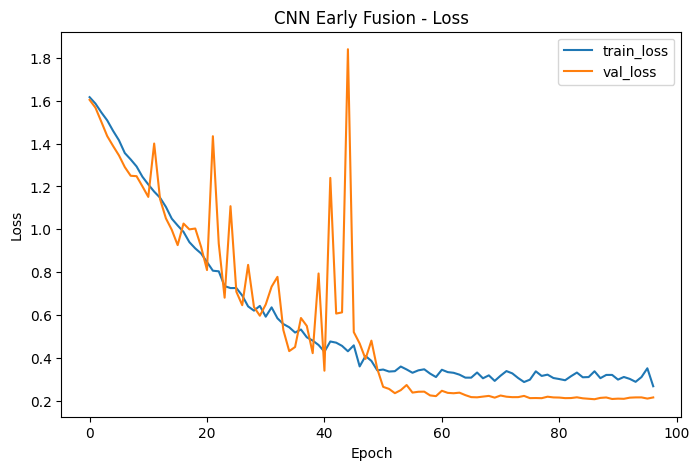

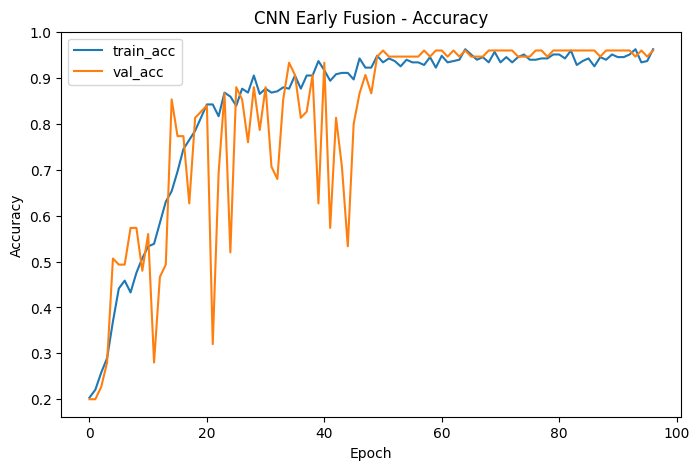

In [31]:
# ============================================
# Cell T17: plot training curves
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_TYPE} Early Fusion - Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_TYPE} Early Fusion - Accuracy")
plt.legend()
plt.show()

In [32]:
# ============================================
# Cell T18: sanity check one batch through model
# ============================================
inputs_tuple, labels, session_ids = next(iter(train_loader))
batch = unpack_batch_inputs(inputs_tuple)
batch = move_batch_to_device(batch, DEVICE)

with torch.no_grad():
    logits = model(
        video=batch["video"],
        body=batch["body"],
        hand=batch["hand"],
    )

print("logits shape:", logits.shape)
print("labels shape:", labels.shape)
print("session ids example:", session_ids[:3])

logits shape: torch.Size([16, 5])
labels shape: torch.Size([16])
session ids example: ['session_0051', 'session_0082', 'session_0013']


Now the logger

In [33]:
# ============================================
# Cell X1: logger imports
# ============================================
import os
import json
import csv
import shutil
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [34]:
# ============================================
# Cell X2: logger config
# ============================================
LOGGER_ROOT = "./logger"

# set this if you want a custom experiment note in folder name
RUN_NOTE = "early_fusion"

os.makedirs(LOGGER_ROOT, exist_ok=True)

In [35]:
# ============================================
# Cell X3: helper functions for logging
# ============================================
def get_modalities_tag(video_enabled, body_enabled, hand_enabled):
    tags = []
    if video_enabled:
        tags.append("video")
    if body_enabled:
        tags.append("body")
    if hand_enabled:
        tags.append("hand")
    if len(tags) == 0:
        return "none"
    return "+".join(tags)


def make_run_name(
    model_type,
    lr,
    epochs,
    video_enabled,
    body_enabled,
    hand_enabled,
    note="",
):
    modalities_tag = get_modalities_tag(video_enabled, body_enabled, hand_enabled)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    lr_str = f"{lr:.0e}" if lr < 1e-3 else str(lr).replace(".", "p")
    name_parts = [
        timestamp,
        model_type,
        f"lr_{lr_str}",
        f"ep_{epochs}",
        modalities_tag,
    ]
    if note is not None and len(str(note).strip()) > 0:
        name_parts.append(str(note).strip().replace(" ", "_"))
    return "__".join(name_parts)


def make_run_dir(
    logger_root,
    model_type,
    lr,
    epochs,
    video_enabled,
    body_enabled,
    hand_enabled,
    note="",
):
    run_name = make_run_name(
        model_type=model_type,
        lr=lr,
        epochs=epochs,
        video_enabled=video_enabled,
        body_enabled=body_enabled,
        hand_enabled=hand_enabled,
        note=note,
    )
    run_dir = os.path.join(logger_root, run_name)
    os.makedirs(run_dir, exist_ok=True)
    return run_name, run_dir


def safe_to_python(obj):
    """
    Convert objects into JSON-serializable form.
    """
    if isinstance(obj, (str, int, float, bool)) or obj is None:
        return obj
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.device):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (list, tuple)):
        return [safe_to_python(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): safe_to_python(v) for k, v in obj.items()}
    return str(obj)


def flatten_dict(d, parent_key="", sep="."):
    """
    Flatten nested dict for meta csv.
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def get_model_structure_text(model):
    return str(model)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [36]:
# ============================================
# Cell X4: collect config
# ============================================
def build_run_config(model):
    total_params, trainable_params = count_parameters(model)

    config = {
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "run_note": RUN_NOTE,
        },
        "data": {
            "DATA_ROOT": DATA_ROOT,
            "LABELS": LABELS,
            "NUM_CLASSES": NUM_CLASSES,
            "VIDEO_INPUT_ENABLED": VIDEO_INPUT_ENABLED,
            "BODY_POSE_INPUT_ENABLED": BODY_POSE_INPUT_ENABLED,
            "HAND_POSE_INPUT_ENABLED": HAND_POSE_INPUT_ENABLED,
            "BODY_LANDMARK_USED": BODY_LANDMARK_USED,
            "BATCH_SIZE": BATCH_SIZE,
            "NUM_WORKERS": NUM_WORKERS,
            "VIDEO_SIZE": VIDEO_SIZE,
            "VIDEO_NORMALIZE": VIDEO_NORMALIZE,
            "VIDEO_PAD_LENGTH": VIDEO_PAD_LENGTH,
            "BODY_PAD_LENGTH": BODY_PAD_LENGTH,
            "HAND_PAD_LENGTH": HAND_PAD_LENGTH,
            "TRUNCATE_IF_LONGER": TRUNCATE_IF_LONGER,
            "REQUIRE_ALL_THREE_COMPONENTS": REQUIRE_ALL_THREE_COMPONENTS,
            "VERBOSE_SCREENING": VERBOSE_SCREENING,
            "TRAIN_RATIO": TRAIN_RATIO,
            "VAL_RATIO": VAL_RATIO,
            "TEST_RATIO": TEST_RATIO,
            "RANDOM_SEED": RANDOM_SEED,
            "STRATIFY_SPLIT": STRATIFY_SPLIT,
        },
        "model": {
            "MODEL_TYPE": MODEL_TYPE,
            "VIDEO_FEATURE_DIM": VIDEO_FEATURE_DIM,
            "USE_BODY_MLP": USE_BODY_MLP,
            "BODY_FEATURE_DIM": BODY_FEATURE_DIM,
            "USE_HAND_MLP": USE_HAND_MLP,
            "HAND_FEATURE_DIM": HAND_FEATURE_DIM,
            "LSTM_HIDDEN_DIM": LSTM_HIDDEN_DIM,
            "LSTM_NUM_LAYERS": LSTM_NUM_LAYERS,
            "LSTM_DROPOUT": LSTM_DROPOUT,
            "LSTM_BIDIRECTIONAL": LSTM_BIDIRECTIONAL,
            "CNN_HIDDEN_DIM": CNN_HIDDEN_DIM,
            "CNN_DROPOUT": CNN_DROPOUT,
            "CLASSIFIER_HIDDEN_DIM": CLASSIFIER_HIDDEN_DIM,
            "DROPOUT": DROPOUT,
            "model_structure": get_model_structure_text(model),
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
        },
        "training": {
            "DEVICE": str(DEVICE),
            "EPOCHS": EPOCHS,
            "LEARNING_RATE": LEARNING_RATE,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "USE_CLASS_WEIGHTS": USE_CLASS_WEIGHTS,
            "USE_LR_SCHEDULER": USE_LR_SCHEDULER,
            "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
            "EARLY_STOPPING_MIN_DELTA": EARLY_STOPPING_MIN_DELTA,
        },
    }

    return safe_to_python(config)

In [37]:
# ============================================
# Cell X5: logger save functions
# ============================================
def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(safe_to_python(obj), f, indent=2, ensure_ascii=False)


def save_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(str(text))


def save_history_csv(path, history):
    df = pd.DataFrame(history)
    df.to_csv(path, index=False)


def save_metrics_csv(path, metrics_dict):
    df = pd.DataFrame([metrics_dict])
    df.to_csv(path, index=False)


def save_predictions_csv(path, y_true, y_pred, label_names, session_ids=None):
    rows = []
    for i in range(len(y_true)):
        row = {
            "index": i,
            "y_true_idx": int(y_true[i]),
            "y_true_name": label_names[int(y_true[i])],
            "y_pred_idx": int(y_pred[i]),
            "y_pred_name": label_names[int(y_pred[i])],
        }
        if session_ids is not None and i < len(session_ids):
            row["session_id"] = session_ids[i]
        rows.append(row)

    pd.DataFrame(rows).to_csv(path, index=False)


def plot_and_save_training_curves(history, run_dir, title_prefix):
    epochs_range = list(range(1, len(history["train_loss"]) + 1))

    loss_plot_path = os.path.join(run_dir, "loss_curve.png")
    acc_plot_path = os.path.join(run_dir, "accuracy_curve.png")

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="train_loss")
    plt.plot(epochs_range, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_plot_path, dpi=200)
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], label="train_acc")
    plt.plot(epochs_range, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(acc_plot_path, dpi=200)
    plt.close()

    return loss_plot_path, acc_plot_path


def save_confusion_matrix_plot(cm, label_names, run_dir, title_prefix):
    fig_path = os.path.join(run_dir, "confusion_matrix.png")

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title_prefix} - Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(label_names))
    plt.xticks(tick_marks, label_names, rotation=45, ha="right")
    plt.yticks(tick_marks, label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.close()

    return fig_path


def append_meta_csv(meta_csv_path, row_dict):
    row_dict = safe_to_python(row_dict)

    if os.path.isfile(meta_csv_path):
        df_old = pd.read_csv(meta_csv_path)
        df_new = pd.DataFrame([row_dict])

        all_cols = sorted(set(df_old.columns).union(set(df_new.columns)))
        df_old = df_old.reindex(columns=all_cols)
        df_new = df_new.reindex(columns=all_cols)

        df_all = pd.concat([df_old, df_new], ignore_index=True)
        df_all.to_csv(meta_csv_path, index=False)
    else:
        pd.DataFrame([row_dict]).to_csv(meta_csv_path, index=False)

In [38]:
# ============================================
# Cell X6: evaluate with session ids
# ============================================
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support


def evaluate_loader_with_ids(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []
    all_session_ids = []

    with torch.no_grad():
        for inputs_tuple, labels, session_ids in loader:
            batch = unpack_batch_inputs(inputs_tuple)
            batch = move_batch_to_device(batch, device)
            labels = labels.to(device)

            logits = model(
                video=batch["video"],
                body=batch["body"],
                hand=batch["hand"],
            )

            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (preds == labels).sum().item()
            running_total += batch_size

            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())
            all_session_ids.extend(session_ids)

    avg_loss = running_loss / max(running_total, 1)
    avg_acc = running_correct / max(running_total, 1)

    return {
        "loss": avg_loss,
        "acc": avg_acc,
        "preds": all_preds,
        "labels": all_labels,
        "session_ids": all_session_ids,
    }

In [39]:
# ============================================
# Cell X7: main logger function
# ============================================
def finalize_and_log_run(
    model,
    history,
    best_model_path,
    train_metrics,
    val_metrics,
    test_metrics,
    logger_root="./logger",
    meta_csv_name="meta_runs.csv",
):
    # ----------------------------------------
    # Make run folder
    # ----------------------------------------
    run_name, run_dir = make_run_dir(
        logger_root=logger_root,
        model_type=MODEL_TYPE,
        lr=LEARNING_RATE,
        epochs=EPOCHS,
        video_enabled=VIDEO_INPUT_ENABLED,
        body_enabled=BODY_POSE_INPUT_ENABLED,
        hand_enabled=HAND_POSE_INPUT_ENABLED,
        note=RUN_NOTE,
    )

    title_prefix = (
        f"{MODEL_TYPE} | lr={LEARNING_RATE} | ep={EPOCHS} | "
        f"mods={get_modalities_tag(VIDEO_INPUT_ENABLED, BODY_POSE_INPUT_ENABLED, HAND_POSE_INPUT_ENABLED)}"
    )

    # ----------------------------------------
    # Save config
    # ----------------------------------------
    config = build_run_config(model)
    config["paths"] = {
        "run_dir": run_dir,
        "best_model_source_path": best_model_path,
    }

    save_json(os.path.join(run_dir, "config.json"), config)
    save_text(os.path.join(run_dir, "model_structure.txt"), get_model_structure_text(model))

    # ----------------------------------------
    # Save training history
    # ----------------------------------------
    save_history_csv(os.path.join(run_dir, "history.csv"), history)
    loss_plot_path, acc_plot_path = plot_and_save_training_curves(history, run_dir, title_prefix)

    # ----------------------------------------
    # Save checkpoint into run dir
    # ----------------------------------------
    checkpoint_dst = os.path.join(run_dir, "best_model.pt")
    if os.path.isfile(best_model_path):
        shutil.copy2(best_model_path, checkpoint_dst)
    else:
        torch.save(model.state_dict(), checkpoint_dst)

    # ----------------------------------------
    # Save result metrics
    # ----------------------------------------
    y_true = test_metrics["labels"]
    y_pred = test_metrics["preds"]
    session_ids = test_metrics["session_ids"]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_path = save_confusion_matrix_plot(cm, LABELS, run_dir, title_prefix)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    save_json(os.path.join(run_dir, "classification_report.json"), report_dict)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result_metrics = {
        "run_name": run_name,
        "train_loss_last": float(history["train_loss"][-1]),
        "train_acc_last": float(history["train_acc"][-1]),
        "val_loss_last": float(history["val_loss"][-1]),
        "val_acc_last": float(history["val_acc"][-1]),
        "test_loss": float(test_metrics["loss"]),
        "test_acc": float(test_metrics["acc"]),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
    }

    save_json(os.path.join(run_dir, "result_metrics.json"), result_metrics)
    save_metrics_csv(os.path.join(run_dir, "result_metrics.csv"), result_metrics)
    save_predictions_csv(
        os.path.join(run_dir, "test_predictions.csv"),
        y_true=y_true,
        y_pred=y_pred,
        label_names=LABELS,
        session_ids=session_ids,
    )

    # Also save raw train/val metrics if you want
    save_json(os.path.join(run_dir, "train_metrics.json"), train_metrics)
    save_json(os.path.join(run_dir, "val_metrics.json"), val_metrics)
    save_json(os.path.join(run_dir, "test_metrics_full.json"), test_metrics)

    # ----------------------------------------
    # Save confusion matrix csv
    # ----------------------------------------
    cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)
    cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"))

    # ----------------------------------------
    # Append meta csv
    # ----------------------------------------
    flattened_config = flatten_dict(config)
    meta_row = {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "loss_plot_path": loss_plot_path,
        "acc_plot_path": acc_plot_path,
        "cm_plot_path": cm_path,
        **result_metrics,
        **flattened_config,
    }

    meta_csv_path = os.path.join(logger_root, meta_csv_name)
    append_meta_csv(meta_csv_path, meta_row)

    print("Run logged to:", run_dir)
    print("Meta CSV updated:", meta_csv_path)

    return {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "meta_csv_path": meta_csv_path,
    }

In [40]:
# ============================================
# Cell X8: run this after training is finished
# ============================================
# Reload best model first, if needed
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# Re-evaluate train / val / test with session ids
train_metrics_logged = evaluate_loader_with_ids(model, train_loader, criterion, DEVICE)
val_metrics_logged = evaluate_loader_with_ids(model, val_loader, criterion, DEVICE)
test_metrics_logged = evaluate_loader_with_ids(model, test_loader, criterion, DEVICE)

log_info = finalize_and_log_run(
    model=model,
    history=history,
    best_model_path=BEST_MODEL_PATH,
    train_metrics=train_metrics_logged,
    val_metrics=val_metrics_logged,
    test_metrics=test_metrics_logged,
    logger_root=LOGGER_ROOT,
    meta_csv_name="meta_runs.csv",
)

log_info

Run logged to: ./logger/20260320_182331__CNN__lr_1e-04__ep_400__body+hand__early_fusion
Meta CSV updated: ./logger/meta_runs.csv


{'run_name': '20260320_182331__CNN__lr_1e-04__ep_400__body+hand__early_fusion',
 'run_dir': './logger/20260320_182331__CNN__lr_1e-04__ep_400__body+hand__early_fusion',
 'checkpoint_path': './logger/20260320_182331__CNN__lr_1e-04__ep_400__body+hand__early_fusion/best_model.pt',
 'meta_csv_path': './logger/meta_runs.csv'}

In [41]:
# ============================================
# Cell X9: optional quick viewer for the meta csv
# ============================================
meta_csv_path = os.path.join(LOGGER_ROOT, "meta_runs.csv")
if os.path.isfile(meta_csv_path):
    meta_df = pd.read_csv(meta_csv_path)
    display(meta_df.tail(100))
else:
    print("No meta csv found yet.")

,acc_plot_path,checkpoint_path,cm_plot_path,data.BATCH_SIZE,data.BODY_LANDMARK_USED,data.BODY_PAD_LENGTH,data.BODY_POSE_INPUT_ENABLED,data.DATA_ROOT,data.HAND_PAD_LENGTH,data.HAND_POSE_INPUT_ENABLED,...,training.DEVICE,training.EARLY_STOPPING_MIN_DELTA,training.EARLY_STOPPING_PATIENCE,training.EPOCHS,training.LEARNING_RATE,training.USE_CLASS_WEIGHTS,training.USE_LR_SCHEDULER,training.WEIGHT_DECAY,val_acc_last,val_loss_last
0,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,./logger/20260320_152516__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0001,False,True,0.0001,0.960000,0.158404
1,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,./logger/20260320_152647__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,cuda,NaN,NaN,400,0.0001,False,True,0.0001,0.960000,0.227696
2,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,./logger/20260320_152934__CNN__lr_1e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0001,False,True,0.0001,0.986667,0.086058
3,./logger/20260320_153137__CNN__lr_0p01__ep_400...,./logger/20260320_153137__CNN__lr_0p01__ep_400...,./logger/20260320_153137__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0100,False,True,0.0001,0.933333,0.180644
4,./logger/20260320_153322__CNN__lr_0p01__ep_400...,./logger/20260320_153322__CNN__lr_0p01__ep_400...,./logger/20260320_153322__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0100,False,True,0.0001,0.933333,0.205436
5,./logger/20260320_153442__CNN__lr_0p01__ep_400...,./logger/20260320_153442__CNN__lr_0p01__ep_400...,./logger/20260320_153442__CNN__lr_0p01__ep_400...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,cuda,NaN,NaN,400,0.0100,False,True,0.0001,0.893333,0.392276
6,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,./logger/20260320_153729__LSTM__lr_3e-04__ep_4...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,hand_dummy/data,64,False,...,cuda,NaN,NaN,400,0.0003,False,True,0.0001,0.373333,1.515263
7,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,./logger/20260320_153930__LSTM__lr_3e-04__ep_4...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0003,False,True,0.0001,0.213333,1.608784
8,./logger/20260320_160615__CNN__lr_3e-04__ep_40...,./logger/20260320_160615__CNN__lr_3e-04__ep_40...,./logger/20260320_160615__CNN__lr_3e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0003,False,True,0.0001,0.960000,0.127844
9,./logger/20260320_160815__CNN__lr_3e-04__ep_40...,./logger/20260320_160815__CNN__lr_3e-04__ep_40...,./logger/20260320_160815__CNN__lr_3e-04__ep_40...,16,"[5, 6, 7, 8, 9, 10, 11, 12]",64,False,hand_dummy/data,64,True,...,cuda,NaN,NaN,400,0.0003,False,True,0.0001,0.946667,0.175263


Now we try finetuning

In [153]:
# ============================================
# Cell FT1: finetuning config
# ============================================
import os
import json
import copy
import time
import shutil
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support


# ------------------------------------------------
# Paths
# ------------------------------------------------
FINETUNING_DATA_ROOT = "./hand_dummy/data_finetune"
PRETRAINED_RUN_DIR = "./logger/20260320_152934__CNN__lr_1e-04__ep_400__body+hand__early_fusion"
FINETUNE_LOGGER_ROOT = "./logger_finetuning"

os.makedirs(FINETUNE_LOGGER_ROOT, exist_ok=True)

# ------------------------------------------------
# Finetuning split
# ------------------------------------------------
FINETUNE_NUM_SAMPLES = 50
FINETUNE_RANDOM_SEED = 42
FINETUNE_STRATIFY = True

# ------------------------------------------------
# Finetuning mode
# ------------------------------------------------
INFERENCE_ONLY = False   # True = no training, directly evaluate on new dataset split

# ------------------------------------------------
# Finetuning training
# ------------------------------------------------
FINETUNE_EPOCHS = 200
FINETUNE_LEARNING_RATE = 1e-2
FINETUNE_WEIGHT_DECAY = 1e-4
FINETUNE_BATCH_SIZE = 4
FINETUNE_NUM_WORKERS = 0
FINETUNE_USE_CLASS_WEIGHTS = False
FINETUNE_USE_LR_SCHEDULER = True

# ------------------------------------------------
# Early Stopping
# ------------------------------------------------
EARLY_STOPPING_PATIENCE = 20
EARLY_STOPPING_MIN_DELTA = 1e-4

# ------------------------------------------------
# Notes
# ------------------------------------------------
FINETUNE_RUN_NOTE = "classifier_head_only"

In [154]:
# ============================================
# Cell FT2: load old run config and checkpoint
# ============================================
def load_previous_run_artifacts(run_dir):
    config_path = os.path.join(run_dir, "config.json")
    checkpoint_path = os.path.join(run_dir, "best_model.pt")

    if not os.path.isfile(config_path):
        raise FileNotFoundError(f"config.json not found in: {run_dir}")
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"best_model.pt not found in: {run_dir}")

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return cfg, checkpoint_path


previous_cfg, PRETRAINED_CHECKPOINT_PATH = load_previous_run_artifacts(PRETRAINED_RUN_DIR)

print("Loaded previous run config from:", PRETRAINED_RUN_DIR)
print("Checkpoint path:", PRETRAINED_CHECKPOINT_PATH)

Loaded previous run config from: ./logger/20260320_152934__CNN__lr_1e-04__ep_400__body+hand__early_fusion
Checkpoint path: ./logger/20260320_152934__CNN__lr_1e-04__ep_400__body+hand__early_fusion/best_model.pt


In [155]:
# ============================================
# Cell FT3: extract settings from old config
# ============================================
# ------------------------------------------------
# Data / modality settings from previous run
# ------------------------------------------------
OLD_LABELS = previous_cfg["data"]["LABELS"]
OLD_NUM_CLASSES = previous_cfg["data"]["NUM_CLASSES"]

OLD_VIDEO_INPUT_ENABLED = previous_cfg["data"]["VIDEO_INPUT_ENABLED"]
OLD_BODY_POSE_INPUT_ENABLED = previous_cfg["data"]["BODY_POSE_INPUT_ENABLED"]
OLD_HAND_POSE_INPUT_ENABLED = previous_cfg["data"]["HAND_POSE_INPUT_ENABLED"]
OLD_BODY_LANDMARK_USED = previous_cfg["data"]["BODY_LANDMARK_USED"]

OLD_VIDEO_SIZE = tuple(previous_cfg["data"]["VIDEO_SIZE"])
OLD_VIDEO_NORMALIZE = previous_cfg["data"]["VIDEO_NORMALIZE"]
OLD_VIDEO_PAD_LENGTH = previous_cfg["data"]["VIDEO_PAD_LENGTH"]
OLD_BODY_PAD_LENGTH = previous_cfg["data"]["BODY_PAD_LENGTH"]
OLD_HAND_PAD_LENGTH = previous_cfg["data"]["HAND_PAD_LENGTH"]
OLD_TRUNCATE_IF_LONGER = previous_cfg["data"]["TRUNCATE_IF_LONGER"]
OLD_REQUIRE_ALL_THREE_COMPONENTS = previous_cfg["data"]["REQUIRE_ALL_THREE_COMPONENTS"]

# ------------------------------------------------
# Model settings from previous run
# ------------------------------------------------
OLD_MODEL_TYPE = previous_cfg["model"]["MODEL_TYPE"]

OLD_VIDEO_FEATURE_DIM = previous_cfg["model"]["VIDEO_FEATURE_DIM"]
OLD_USE_BODY_MLP = previous_cfg["model"]["USE_BODY_MLP"]
OLD_BODY_FEATURE_DIM = previous_cfg["model"]["BODY_FEATURE_DIM"]
OLD_USE_HAND_MLP = previous_cfg["model"]["USE_HAND_MLP"]
OLD_HAND_FEATURE_DIM = previous_cfg["model"]["HAND_FEATURE_DIM"]

OLD_LSTM_HIDDEN_DIM = previous_cfg["model"]["LSTM_HIDDEN_DIM"]
OLD_LSTM_NUM_LAYERS = previous_cfg["model"]["LSTM_NUM_LAYERS"]
OLD_LSTM_DROPOUT = previous_cfg["model"]["LSTM_DROPOUT"]
OLD_LSTM_BIDIRECTIONAL = previous_cfg["model"]["LSTM_BIDIRECTIONAL"]

OLD_CNN_HIDDEN_DIM = previous_cfg["model"]["CNN_HIDDEN_DIM"]
OLD_CNN_DROPOUT = previous_cfg["model"]["CNN_DROPOUT"]

OLD_CLASSIFIER_HIDDEN_DIM = previous_cfg["model"]["CLASSIFIER_HIDDEN_DIM"]
OLD_DROPOUT = previous_cfg["model"]["DROPOUT"]

print("OLD_MODEL_TYPE:", OLD_MODEL_TYPE)
print("OLD modalities:",
      f"video={OLD_VIDEO_INPUT_ENABLED}, body={OLD_BODY_POSE_INPUT_ENABLED}, hand={OLD_HAND_POSE_INPUT_ENABLED}")

OLD_MODEL_TYPE: CNN
OLD modalities: video=False, body=True, hand=True


In [156]:
# ============================================
# Cell FT4: finetune dataset setup
# ============================================
# Make sure your earlier dataset class uses the global TRUNCATE_IF_LONGER.
# We update it here to match the pretrained run.
TRUNCATE_IF_LONGER = OLD_TRUNCATE_IF_LONGER

finetune_full_dataset = GestureEpisodeDataset(
    data_root=FINETUNING_DATA_ROOT,
    labels=OLD_LABELS,
    video_input_enabled=OLD_VIDEO_INPUT_ENABLED,
    body_pose_input_enabled=OLD_BODY_POSE_INPUT_ENABLED,
    hand_pose_input_enabled=OLD_HAND_POSE_INPUT_ENABLED,
    body_landmark_used=OLD_BODY_LANDMARK_USED,
    video_size=OLD_VIDEO_SIZE,
    video_normalize=OLD_VIDEO_NORMALIZE,
    video_pad_length=OLD_VIDEO_PAD_LENGTH,
    body_pad_length=OLD_BODY_PAD_LENGTH,
    hand_pad_length=OLD_HAND_PAD_LENGTH,
    require_all_three_components=OLD_REQUIRE_ALL_THREE_COMPONENTS,
    verbose_screening=True,
)

print("Finetuning full dataset size:", len(finetune_full_dataset))

Valid samples: 259
Skipped samples: 0
Finetuning full dataset size: 259


In [157]:
# ============================================
# Cell FT5: choose a portion for finetuning, rest for validation
# ============================================
def make_finetune_val_subsets(
    dataset,
    finetune_num_samples,
    random_seed=42,
    stratify=True,
):
    total_n = len(dataset)
    if finetune_num_samples <= 0:
        raise ValueError("FINETUNE_NUM_SAMPLES must be > 0")
    if finetune_num_samples >= total_n:
        raise ValueError(
            f"FINETUNE_NUM_SAMPLES ({finetune_num_samples}) must be smaller than dataset size ({total_n})"
        )

    indices = list(range(total_n))
    labels = [dataset.samples[i]["label_idx"] for i in indices]
    stratify_labels = labels if stratify else None

    ft_indices, val_indices = train_test_split(
        indices,
        train_size=finetune_num_samples,
        random_state=random_seed,
        stratify=stratify_labels,
    )

    ft_subset = Subset(dataset, ft_indices)
    val_subset = Subset(dataset, val_indices)
    return ft_subset, val_subset, ft_indices, val_indices


def summarize_subset_from_base(subset, base_dataset, name="subset"):
    counts = {}
    for idx in subset.indices:
        label_name = base_dataset.samples[idx]["label_name"]
        counts[label_name] = counts.get(label_name, 0) + 1

    print(f"{name}: {len(subset)} samples")
    for label in OLD_LABELS:
        print(f"  {label}: {counts.get(label, 0)}")


finetune_train_dataset, finetune_val_dataset, ft_indices, ft_val_indices = make_finetune_val_subsets(
    dataset=finetune_full_dataset,
    finetune_num_samples=FINETUNE_NUM_SAMPLES,
    random_seed=FINETUNE_RANDOM_SEED,
    stratify=FINETUNE_STRATIFY,
)

summarize_subset_from_base(finetune_train_dataset, finetune_full_dataset, "finetune_train")
summarize_subset_from_base(finetune_val_dataset, finetune_full_dataset, "finetune_val")

finetune_train: 50 samples
  go: 10
  stop: 10
  left: 10
  right: 10
  null: 10
finetune_val: 209 samples
  go: 41
  stop: 41
  left: 45
  right: 41
  null: 41


In [158]:
# ============================================
# Cell FT6: finetune loaders
# ============================================
finetune_train_loader = DataLoader(
    finetune_train_dataset,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True,
    num_workers=FINETUNE_NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

finetune_val_loader = DataLoader(
    finetune_val_dataset,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    num_workers=FINETUNE_NUM_WORKERS,
    collate_fn=gesture_collate_fn_stacked,
)

print("finetune train batches:", len(finetune_train_loader))
print("finetune val batches:", len(finetune_val_loader))

finetune train batches: 13
finetune val batches: 53


In [159]:
# ============================================
# Cell FT7: rebuild model exactly from previous run
# ============================================
def build_model_from_previous_config(cfg):
    model_type = cfg["model"]["MODEL_TYPE"]
    body_landmarks_used = cfg["data"]["BODY_LANDMARK_USED"]
    num_body_landmarks_used = 17 if body_landmarks_used is None else len(body_landmarks_used)

    common_kwargs = dict(
        num_classes=cfg["data"]["NUM_CLASSES"],
        video_input_enabled=cfg["data"]["VIDEO_INPUT_ENABLED"],
        body_pose_input_enabled=cfg["data"]["BODY_POSE_INPUT_ENABLED"],
        hand_pose_input_enabled=cfg["data"]["HAND_POSE_INPUT_ENABLED"],
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=cfg["model"]["VIDEO_FEATURE_DIM"],
        use_body_mlp=cfg["model"]["USE_BODY_MLP"],
        body_feature_dim=cfg["model"]["BODY_FEATURE_DIM"],
        use_hand_mlp=cfg["model"]["USE_HAND_MLP"],
        hand_feature_dim=cfg["model"]["HAND_FEATURE_DIM"],
        classifier_hidden_dim=cfg["model"]["CLASSIFIER_HIDDEN_DIM"],
        classifier_dropout=cfg["model"]["DROPOUT"],
    )

    if model_type == "LSTM":
        model = GestureLSTMClassifier(
            **common_kwargs,
            hidden_dim=cfg["model"]["LSTM_HIDDEN_DIM"],
            num_layers=cfg["model"]["LSTM_NUM_LAYERS"],
            dropout=cfg["model"]["LSTM_DROPOUT"],
            bidirectional=cfg["model"]["LSTM_BIDIRECTIONAL"],
        )
    elif model_type == "CNN":
        model = GestureCNNClassifier(
            **common_kwargs,
            hidden_dim=cfg["model"]["CNN_HIDDEN_DIM"],
            dropout=cfg["model"]["CNN_DROPOUT"],
        )
    else:
        raise ValueError(f"Unsupported MODEL_TYPE: {model_type}")

    return model


finetune_model = build_model_from_previous_config(previous_cfg)
finetune_model.load_state_dict(torch.load(PRETRAINED_CHECKPOINT_PATH, map_location=DEVICE))
finetune_model = finetune_model.to(DEVICE)

print(finetune_model)
print("Loaded pretrained weights.")

GestureCNNClassifier(
  (encoder): MultiModalEarlyFusionEncoder(
    (body_encoder): BodyEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=32, bias=True)
        (1): ReLU(inplace=True)
      )
    )
    (hand_encoder): HandEncoder(
      (net): Sequential(
        (0): Linear(in_features=42, out_features=32, bias=True)
        (1): ReLU(inplace=True)
      )
    )
  )
  (temporal_conv): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, m

In [160]:
# ============================================
# Cell FT8: freeze everything except classifier
# ============================================
def freeze_for_classifier_only_finetuning(model):
    for p in model.parameters():
        p.requires_grad = False

    if not hasattr(model, "classifier"):
        raise ValueError("Model does not have a .classifier module to finetune.")

    for p in model.classifier.parameters():
        p.requires_grad = True

    return model


def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for _, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()

    print("Total parameters    :", total)
    print("Trainable parameters:", trainable)


finetune_model = freeze_for_classifier_only_finetuning(finetune_model)
print_trainable_parameters(finetune_model)

Total parameters    : 143109
Trainable parameters: 17157


In [161]:
# ============================================
# Cell FT9: finetuning loss / optimizer / scheduler
# ============================================
def compute_class_weights_from_subset_base(subset, base_dataset, num_classes):
    counts = np.zeros(num_classes, dtype=np.float32)
    for idx in subset.indices:
        label_idx = base_dataset.samples[idx]["label_idx"]
        counts[label_idx] += 1.0

    counts[counts == 0] = 1.0
    weights = counts.sum() / counts
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


if FINETUNE_USE_CLASS_WEIGHTS:
    ft_class_weights = compute_class_weights_from_subset_base(
        finetune_train_dataset,
        finetune_full_dataset,
        OLD_NUM_CLASSES,
    ).to(DEVICE)
else:
    ft_class_weights = None

finetune_criterion = nn.CrossEntropyLoss(weight=ft_class_weights)

finetune_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=FINETUNE_LEARNING_RATE,
    weight_decay=FINETUNE_WEIGHT_DECAY,
)

if FINETUNE_USE_LR_SCHEDULER:
    finetune_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        finetune_optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )
else:
    finetune_scheduler = None

In [162]:
# ============================================
# Cell FT10: finetuning checkpoint path
# ============================================
def get_ft_modalities_tag(cfg):
    tags = []
    if cfg["data"]["VIDEO_INPUT_ENABLED"]:
        tags.append("video")
    if cfg["data"]["BODY_POSE_INPUT_ENABLED"]:
        tags.append("body")
    if cfg["data"]["HAND_POSE_INPUT_ENABLED"]:
        tags.append("hand")
    return "+".join(tags) if len(tags) > 0 else "none"


FT_MODALITIES_TAG = get_ft_modalities_tag(previous_cfg)
FT_MODEL_TYPE = previous_cfg["model"]["MODEL_TYPE"]

FINETUNE_CKPT_NAME = (
    f"best_finetune__{FT_MODEL_TYPE}"
    f"__lr_{str(FINETUNE_LEARNING_RATE).replace('.', 'p')}"
    f"__ep_{FINETUNE_EPOCHS}"
    f"__n_{FINETUNE_NUM_SAMPLES}"
    f"__{FT_MODALITIES_TAG}.pt"
)

FINETUNE_TMP_CKPT_PATH = os.path.join(FINETUNE_LOGGER_ROOT, FINETUNE_CKPT_NAME)
print(FINETUNE_TMP_CKPT_PATH)

./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_50__body+hand.pt


In [163]:
# ============================================
# Cell FT11: finetuning training loop with early stopping
# ============================================
finetune_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

ft_best_val_loss = float("inf")
ft_best_val_acc = 0.0
ft_best_epoch = -1
ft_best_state_dict = copy.deepcopy(finetune_model.state_dict())

epochs_without_improvement = 0
early_stopped = False
early_stop_reason = ""

if INFERENCE_ONLY:
    print("INFERENCE_ONLY=True, skipping finetuning.")
    torch.save(finetune_model.state_dict(), FINETUNE_TMP_CKPT_PATH)
else:
    for epoch in range(FINETUNE_EPOCHS):
        start_time = time.time()

        ft_train_metrics = run_one_epoch(
            model=finetune_model,
            loader=finetune_train_loader,
            optimizer=finetune_optimizer,
            criterion=finetune_criterion,
            device=DEVICE,
            train=True,
        )

        ft_val_metrics = run_one_epoch(
            model=finetune_model,
            loader=finetune_val_loader,
            optimizer=finetune_optimizer,
            criterion=finetune_criterion,
            device=DEVICE,
            train=False,
        )

        if finetune_scheduler is not None:
            finetune_scheduler.step(ft_val_metrics["loss"])

        finetune_history["train_loss"].append(ft_train_metrics["loss"])
        finetune_history["train_acc"].append(ft_train_metrics["acc"])
        finetune_history["val_loss"].append(ft_val_metrics["loss"])
        finetune_history["val_acc"].append(ft_val_metrics["acc"])

        epoch_time = time.time() - start_time

        print(
            f"FT Epoch [{epoch+1}/{FINETUNE_EPOCHS}] | "
            f"Train Loss: {ft_train_metrics['loss']:.4f} | "
            f"Train Acc: {ft_train_metrics['acc']:.4f} | "
            f"Val Loss: {ft_val_metrics['loss']:.4f} | "
            f"Val Acc: {ft_val_metrics['acc']:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        improvement = ft_best_val_loss - ft_val_metrics["loss"]

        if improvement > EARLY_STOPPING_MIN_DELTA:
            ft_best_val_loss = ft_val_metrics["loss"]
            ft_best_val_acc = ft_val_metrics["acc"]
            ft_best_epoch = epoch + 1
            ft_best_state_dict = copy.deepcopy(finetune_model.state_dict())
            torch.save(ft_best_state_dict, FINETUNE_TMP_CKPT_PATH)
            epochs_without_improvement = 0
            print("  Saved finetune best checkpoint:", FINETUNE_TMP_CKPT_PATH)
        else:
            epochs_without_improvement += 1
            print(
                f"  No significant val loss improvement. "
                f"Counter: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
            )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            early_stopped = True
            early_stop_reason = (
                f"No val loss improvement > {EARLY_STOPPING_MIN_DELTA} "
                f"for {EARLY_STOPPING_PATIENCE} consecutive epochs."
            )
            print("Early stopping triggered.")
            break

    print("\nFinetuning finished.")
    print("Best epoch   :", ft_best_epoch)
    print("Best val loss:", ft_best_val_loss)
    print("Best val acc :", ft_best_val_acc)
    print("Early stopped:", early_stopped)
    if early_stopped:
        print("Reason:", early_stop_reason)

FT Epoch [1/200] | Train Loss: 2.5277 | Train Acc: 0.2000 | Val Loss: 1.4594 | Val Acc: 0.3301 | Time: 0.11s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_50__body+hand.pt
FT Epoch [2/200] | Train Loss: 1.1566 | Train Acc: 0.5200 | Val Loss: 0.6913 | Val Acc: 0.7847 | Time: 0.12s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_50__body+hand.pt
FT Epoch [3/200] | Train Loss: 1.0226 | Train Acc: 0.6400 | Val Loss: 0.7296 | Val Acc: 0.6938 | Time: 0.06s
  No significant val loss improvement. Counter: 1/20
FT Epoch [4/200] | Train Loss: 0.9061 | Train Acc: 0.6600 | Val Loss: 0.5463 | Val Acc: 0.7990 | Time: 0.07s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_50__body+hand.pt
FT Epoch [5/200] | Train Loss: 1.1522 | Train Acc: 0.5800 | Val Loss: 0.5251 | Val Acc: 0.8182 | Time: 0.08s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN

In [164]:
# ============================================
# Cell FT12: load best finetuned model and evaluate
# ============================================
if os.path.isfile(FINETUNE_TMP_CKPT_PATH):
    finetune_model.load_state_dict(torch.load(FINETUNE_TMP_CKPT_PATH, map_location=DEVICE))

finetune_model = finetune_model.to(DEVICE)
finetune_model.eval()

ft_train_metrics_logged = evaluate_loader_with_ids(
    finetune_model, finetune_train_loader, finetune_criterion, DEVICE
)
ft_val_metrics_logged = evaluate_loader_with_ids(
    finetune_model, finetune_val_loader, finetune_criterion, DEVICE
)

print("Finetune train acc:", round(ft_train_metrics_logged["acc"], 4))
print("Finetune val acc  :", round(ft_val_metrics_logged["acc"], 4))

Finetune train acc: 0.94
Finetune val acc  : 0.9282


In [165]:
# ============================================
# Cell FT13: finetuning logger helpers
# ============================================
def build_finetune_run_config(model, previous_cfg, pretrained_run_dir, pretrained_ckpt_path):
    total_params, trainable_params = count_parameters(model)

    cfg = {
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "run_note": FINETUNE_RUN_NOTE,
            "run_type": "finetuning" if not INFERENCE_ONLY else "inference_only",
        },
        "source_pretrained_run": {
            "pretrained_run_dir": pretrained_run_dir,
            "pretrained_checkpoint_path": pretrained_ckpt_path,
            "pretrained_model_type": previous_cfg["model"]["MODEL_TYPE"],
        },
        "data": {
            "FINETUNING_DATA_ROOT": FINETUNING_DATA_ROOT,
            "LABELS": OLD_LABELS,
            "NUM_CLASSES": OLD_NUM_CLASSES,
            "VIDEO_INPUT_ENABLED": OLD_VIDEO_INPUT_ENABLED,
            "BODY_POSE_INPUT_ENABLED": OLD_BODY_POSE_INPUT_ENABLED,
            "HAND_POSE_INPUT_ENABLED": OLD_HAND_POSE_INPUT_ENABLED,
            "BODY_LANDMARK_USED": OLD_BODY_LANDMARK_USED,
            "VIDEO_SIZE": OLD_VIDEO_SIZE,
            "VIDEO_NORMALIZE": OLD_VIDEO_NORMALIZE,
            "VIDEO_PAD_LENGTH": OLD_VIDEO_PAD_LENGTH,
            "BODY_PAD_LENGTH": OLD_BODY_PAD_LENGTH,
            "HAND_PAD_LENGTH": OLD_HAND_PAD_LENGTH,
            "TRUNCATE_IF_LONGER": OLD_TRUNCATE_IF_LONGER,
            "REQUIRE_ALL_THREE_COMPONENTS": OLD_REQUIRE_ALL_THREE_COMPONENTS,
            "FINETUNE_NUM_SAMPLES": FINETUNE_NUM_SAMPLES,
            "FINETUNE_RANDOM_SEED": FINETUNE_RANDOM_SEED,
            "FINETUNE_STRATIFY": FINETUNE_STRATIFY,
            "FINETUNE_BATCH_SIZE": FINETUNE_BATCH_SIZE,
            "FINETUNE_NUM_WORKERS": FINETUNE_NUM_WORKERS,
        },
        "model": {
            "MODEL_TYPE": OLD_MODEL_TYPE,
            "VIDEO_FEATURE_DIM": OLD_VIDEO_FEATURE_DIM,
            "USE_BODY_MLP": OLD_USE_BODY_MLP,
            "BODY_FEATURE_DIM": OLD_BODY_FEATURE_DIM,
            "USE_HAND_MLP": OLD_USE_HAND_MLP,
            "HAND_FEATURE_DIM": OLD_HAND_FEATURE_DIM,
            "LSTM_HIDDEN_DIM": OLD_LSTM_HIDDEN_DIM,
            "LSTM_NUM_LAYERS": OLD_LSTM_NUM_LAYERS,
            "LSTM_DROPOUT": OLD_LSTM_DROPOUT,
            "LSTM_BIDIRECTIONAL": OLD_LSTM_BIDIRECTIONAL,
            "CNN_HIDDEN_DIM": OLD_CNN_HIDDEN_DIM,
            "CNN_DROPOUT": OLD_CNN_DROPOUT,
            "CLASSIFIER_HIDDEN_DIM": OLD_CLASSIFIER_HIDDEN_DIM,
            "DROPOUT": OLD_DROPOUT,
            "finetune_strategy": "freeze_all_except_classifier",
            "model_structure": get_model_structure_text(model),
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
        },
        "training": {
            "DEVICE": str(DEVICE),
            "INFERENCE_ONLY": INFERENCE_ONLY,
            "FINETUNE_EPOCHS": FINETUNE_EPOCHS,
            "FINETUNE_LEARNING_RATE": FINETUNE_LEARNING_RATE,
            "FINETUNE_WEIGHT_DECAY": FINETUNE_WEIGHT_DECAY,
            "FINETUNE_USE_CLASS_WEIGHTS": FINETUNE_USE_CLASS_WEIGHTS,
            "FINETUNE_USE_LR_SCHEDULER": FINETUNE_USE_LR_SCHEDULER,
            "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
            "EARLY_STOPPING_MIN_DELTA": EARLY_STOPPING_MIN_DELTA,
        },
        "early_stopping_result": {
            "early_stopped": early_stopped,
            "early_stop_reason": early_stop_reason,
            "best_epoch": ft_best_epoch,
            "best_val_loss": None if ft_best_epoch == -1 else float(ft_best_val_loss),
            "best_val_acc": None if ft_best_epoch == -1 else float(ft_best_val_acc),
        },
    }
    return safe_to_python(cfg)

In [166]:
# ============================================
# Cell FT14: finetuning log finalization
# ============================================
def finalize_and_log_finetune_run(
    model,
    finetune_history,
    best_model_path,
    train_metrics,
    val_metrics,
    previous_cfg,
    pretrained_run_dir,
    pretrained_ckpt_path,
    logger_root="./logger_finetuning",
    meta_csv_name="meta_runs_finetuning.csv",
):
    run_mode_tag = "inference_only" if INFERENCE_ONLY else f"n_{FINETUNE_NUM_SAMPLES}"

    run_name, run_dir = make_run_dir(
        logger_root=logger_root,
        model_type=f"FT_{OLD_MODEL_TYPE}",
        lr=FINETUNE_LEARNING_RATE,
        epochs=0 if INFERENCE_ONLY else FINETUNE_EPOCHS,
        video_enabled=OLD_VIDEO_INPUT_ENABLED,
        body_enabled=OLD_BODY_POSE_INPUT_ENABLED,
        hand_enabled=OLD_HAND_POSE_INPUT_ENABLED,
        note=f"{FINETUNE_RUN_NOTE}__{run_mode_tag}",
    )

    title_prefix = (
        f"{'INF' if INFERENCE_ONLY else 'FT'}-{OLD_MODEL_TYPE} | "
        f"lr={FINETUNE_LEARNING_RATE} | "
        f"ep={0 if INFERENCE_ONLY else FINETUNE_EPOCHS} | "
        f"{run_mode_tag} | "
        f"mods={get_modalities_tag(OLD_VIDEO_INPUT_ENABLED, OLD_BODY_POSE_INPUT_ENABLED, OLD_HAND_POSE_INPUT_ENABLED)}"
    )

    config = build_finetune_run_config(
        model=model,
        previous_cfg=previous_cfg,
        pretrained_run_dir=pretrained_run_dir,
        pretrained_ckpt_path=pretrained_ckpt_path,
    )
    config["paths"] = {
        "run_dir": run_dir,
        "best_model_source_path": best_model_path,
    }

    save_json(os.path.join(run_dir, "config.json"), config)
    save_text(os.path.join(run_dir, "model_structure.txt"), get_model_structure_text(model))
    save_history_csv(os.path.join(run_dir, "history.csv"), finetune_history)

    loss_plot_path, acc_plot_path = plot_and_save_training_curves(
        finetune_history, run_dir, title_prefix
    )

    checkpoint_dst = os.path.join(run_dir, "best_model.pt")
    if os.path.isfile(best_model_path):
        shutil.copy2(best_model_path, checkpoint_dst)
    else:
        torch.save(model.state_dict(), checkpoint_dst)

    y_true = val_metrics["labels"]
    y_pred = val_metrics["preds"]
    session_ids = val_metrics["session_ids"]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(OLD_NUM_CLASSES)))
    cm_path = save_confusion_matrix_plot(cm, OLD_LABELS, run_dir, title_prefix)

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=OLD_LABELS,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    save_json(os.path.join(run_dir, "classification_report.json"), report_dict)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result_metrics = {
        "run_name": run_name,
        "mode": "inference_only" if INFERENCE_ONLY else "finetuning",
        "finetune_train_loss_last": None if len(finetune_history["train_loss"]) == 0 else float(finetune_history["train_loss"][-1]),
        "finetune_train_acc_last": None if len(finetune_history["train_acc"]) == 0 else float(finetune_history["train_acc"][-1]),
        "finetune_val_loss_last": None if len(finetune_history["val_loss"]) == 0 else float(finetune_history["val_loss"][-1]),
        "finetune_val_acc_last": None if len(finetune_history["val_acc"]) == 0 else float(finetune_history["val_acc"][-1]),
        "val_loss": float(val_metrics["loss"]),
        "val_acc": float(val_metrics["acc"]),
        "val_precision_macro": float(precision_macro),
        "val_recall_macro": float(recall_macro),
        "val_f1_macro": float(f1_macro),
        "val_precision_weighted": float(precision_weighted),
        "val_recall_weighted": float(recall_weighted),
        "val_f1_weighted": float(f1_weighted),
        "finetune_num_samples": int(FINETUNE_NUM_SAMPLES),
        "early_stopped": early_stopped,
        "best_epoch": ft_best_epoch,
    }

    save_json(os.path.join(run_dir, "result_metrics.json"), result_metrics)
    save_metrics_csv(os.path.join(run_dir, "result_metrics.csv"), result_metrics)
    save_predictions_csv(
        os.path.join(run_dir, "val_predictions.csv"),
        y_true=y_true,
        y_pred=y_pred,
        label_names=OLD_LABELS,
        session_ids=session_ids,
    )

    save_json(os.path.join(run_dir, "train_metrics.json"), train_metrics)
    save_json(os.path.join(run_dir, "val_metrics_full.json"), val_metrics)

    cm_df = pd.DataFrame(cm, index=OLD_LABELS, columns=OLD_LABELS)
    cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"))

    flattened_config = flatten_dict(config)
    meta_row = {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "loss_plot_path": loss_plot_path,
        "acc_plot_path": acc_plot_path,
        "cm_plot_path": cm_path,
        **result_metrics,
        **flattened_config,
    }

    meta_csv_path = os.path.join(logger_root, meta_csv_name)
    append_meta_csv(meta_csv_path, meta_row)

    print("Finetune run logged to:", run_dir)
    print("Finetune meta CSV updated:", meta_csv_path)

    return {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": checkpoint_dst,
        "meta_csv_path": meta_csv_path,
    }

In [167]:
# ============================================
# Cell FT15: save finetuning or inference-only run
# ============================================
finetune_log_info = finalize_and_log_finetune_run(
    model=finetune_model,
    finetune_history=finetune_history,
    best_model_path=FINETUNE_TMP_CKPT_PATH,
    train_metrics=ft_train_metrics_logged,
    val_metrics=ft_val_metrics_logged,
    previous_cfg=previous_cfg,
    pretrained_run_dir=PRETRAINED_RUN_DIR,
    pretrained_ckpt_path=PRETRAINED_CHECKPOINT_PATH,
    logger_root=FINETUNE_LOGGER_ROOT,
    meta_csv_name="meta_runs_finetuning.csv",
)

finetune_log_info

Finetune run logged to: ./logger_finetuning/20260320_182843__FT_CNN__lr_0p01__ep_200__body+hand__classifier_head_only__n_50
Finetune meta CSV updated: ./logger_finetuning/meta_runs_finetuning.csv


{'run_name': '20260320_182843__FT_CNN__lr_0p01__ep_200__body+hand__classifier_head_only__n_50',
 'run_dir': './logger_finetuning/20260320_182843__FT_CNN__lr_0p01__ep_200__body+hand__classifier_head_only__n_50',
 'checkpoint_path': './logger_finetuning/20260320_182843__FT_CNN__lr_0p01__ep_200__body+hand__classifier_head_only__n_50/best_model.pt',
 'meta_csv_path': './logger_finetuning/meta_runs_finetuning.csv'}

In [168]:
# ============================================
# Cell FT16: optional quick view of finetuning meta csv
# ============================================
ft_meta_csv_path = os.path.join(FINETUNE_LOGGER_ROOT, "meta_runs_finetuning.csv")
if os.path.isfile(ft_meta_csv_path):
    ft_meta_df = pd.read_csv(ft_meta_csv_path)
    display(ft_meta_df.tail(100))
else:
    print("No finetuning meta csv found yet.")

,acc_plot_path,best_epoch,checkpoint_path,cm_plot_path,data.BODY_LANDMARK_USED,data.BODY_PAD_LENGTH,data.BODY_POSE_INPUT_ENABLED,data.FINETUNE_BATCH_SIZE,data.FINETUNE_NUM_SAMPLES,data.FINETUNE_NUM_WORKERS,...,training.FINETUNE_WEIGHT_DECAY,training.INFERENCE_ONLY,val_acc,val_f1_macro,val_f1_weighted,val_loss,val_precision_macro,val_precision_weighted,val_recall_macro,val_recall_weighted
0,./logger_finetuning/20260320_182507__FT_CNN__l...,8,./logger_finetuning/20260320_182507__FT_CNN__l...,./logger_finetuning/20260320_182507__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,25,0,...,0.0001,False,0.829060,0.806041,0.808510,0.564612,0.873743,0.874895,0.826783,0.829060
1,./logger_finetuning/20260320_182609__FT_CNN__l...,-1,./logger_finetuning/20260320_182609__FT_CNN__l...,./logger_finetuning/20260320_182609__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,25,0,...,0.0001,True,0.175214,0.060741,0.059702,7.891992,0.036607,0.035981,0.178261,0.175214
2,./logger_finetuning/20260320_182636__FT_CNN__l...,18,./logger_finetuning/20260320_182636__FT_CNN__l...,./logger_finetuning/20260320_182636__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,40,0,...,0.0001,False,0.853881,0.856131,0.854251,0.421289,0.887071,0.888525,0.858288,0.853881
3,./logger_finetuning/20260320_182708__FT_CNN__l...,15,./logger_finetuning/20260320_182708__FT_CNN__l...,./logger_finetuning/20260320_182708__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,50,0,...,0.0001,False,0.913876,0.913321,0.913731,0.389168,0.915706,0.915690,0.913062,0.913876
4,./logger_finetuning/20260320_182730__FT_CNN__l...,37,./logger_finetuning/20260320_182730__FT_CNN__l...,./logger_finetuning/20260320_182730__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,100,0,...,0.0001,False,0.918239,0.916657,0.917343,0.317854,0.925802,0.926676,0.917837,0.918239
5,./logger_finetuning/20260320_182823__FT_CNN__l...,48,./logger_finetuning/20260320_182823__FT_CNN__l...,./logger_finetuning/20260320_182823__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,100,0,...,0.0001,False,0.949686,0.949720,0.949957,0.313893,0.952743,0.953082,0.949526,0.949686
6,./logger_finetuning/20260320_182843__FT_CNN__l...,20,./logger_finetuning/20260320_182843__FT_CNN__l...,./logger_finetuning/20260320_182843__FT_CNN__l...,"[5, 6, 7, 8, 9, 10, 11, 12]",64,True,4,50,0,...,0.0001,False,0.928230,0.926713,0.927470,0.318596,0.932044,0.932909,0.927696,0.928230


Some top level finetuning code

In [214]:
# ============================================
# Cell FT17: top-level finetuning function
# ============================================
def finetune_function(
    finetuning_data_root,
    pretrained_run_dir,
    finetune_num_samples,
    inference_only=False,
    logger_root="./logger_finetuning",
    finetune_run_note="classifier_head_only",
    random_seed=42,
    stratify=True,
    finetune_epochs=15,
    finetune_learning_rate=1e-4,
    finetune_weight_decay=1e-4,
    finetune_batch_size=4,
    finetune_num_workers=0,
    finetune_use_class_weights=False,
    finetune_use_lr_scheduler=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
):
    os.makedirs(logger_root, exist_ok=True)

    # ----------------------------------------
    # Load previous run config and checkpoint
    # ----------------------------------------
    previous_cfg, pretrained_checkpoint_path = load_previous_run_artifacts(pretrained_run_dir)

    old_labels = previous_cfg["data"]["LABELS"]
    old_num_classes = previous_cfg["data"]["NUM_CLASSES"]

    old_video_input_enabled = previous_cfg["data"]["VIDEO_INPUT_ENABLED"]
    old_body_pose_input_enabled = previous_cfg["data"]["BODY_POSE_INPUT_ENABLED"]
    old_hand_pose_input_enabled = previous_cfg["data"]["HAND_POSE_INPUT_ENABLED"]
    old_body_landmark_used = previous_cfg["data"]["BODY_LANDMARK_USED"]

    old_video_size = tuple(previous_cfg["data"]["VIDEO_SIZE"])
    old_video_normalize = previous_cfg["data"]["VIDEO_NORMALIZE"]
    old_video_pad_length = previous_cfg["data"]["VIDEO_PAD_LENGTH"]
    old_body_pad_length = previous_cfg["data"]["BODY_PAD_LENGTH"]
    old_hand_pad_length = previous_cfg["data"]["HAND_PAD_LENGTH"]
    old_truncate_if_longer = previous_cfg["data"]["TRUNCATE_IF_LONGER"]
    old_require_all_three_components = previous_cfg["data"]["REQUIRE_ALL_THREE_COMPONENTS"]

    # dataset class uses this global
    globals()["TRUNCATE_IF_LONGER"] = old_truncate_if_longer

    # ----------------------------------------
    # Build finetuning dataset
    # ----------------------------------------
    finetune_full_dataset = GestureEpisodeDataset(
        data_root=finetuning_data_root,
        labels=old_labels,
        video_input_enabled=old_video_input_enabled,
        body_pose_input_enabled=old_body_pose_input_enabled,
        hand_pose_input_enabled=old_hand_pose_input_enabled,
        body_landmark_used=old_body_landmark_used,
        video_size=old_video_size,
        video_normalize=old_video_normalize,
        video_pad_length=old_video_pad_length,
        body_pad_length=old_body_pad_length,
        hand_pad_length=old_hand_pad_length,
        require_all_three_components=old_require_all_three_components,
        verbose_screening=True,
    )

    print("Finetuning full dataset size:", len(finetune_full_dataset))

    # ----------------------------------------
    # Split: portion for finetuning, rest for validation
    # ----------------------------------------
    finetune_train_dataset, finetune_val_dataset, ft_indices, ft_val_indices = make_finetune_val_subsets(
        dataset=finetune_full_dataset,
        finetune_num_samples=finetune_num_samples,
        random_seed=random_seed,
        stratify=stratify,
    )

    summarize_subset_from_base(finetune_train_dataset, finetune_full_dataset, "finetune_train")
    summarize_subset_from_base(finetune_val_dataset, finetune_full_dataset, "finetune_val")

    finetune_train_loader = DataLoader(
        finetune_train_dataset,
        batch_size=finetune_batch_size,
        shuffle=True,
        num_workers=finetune_num_workers,
        collate_fn=gesture_collate_fn_stacked,
    )

    finetune_val_loader = DataLoader(
        finetune_val_dataset,
        batch_size=finetune_batch_size,
        shuffle=False,
        num_workers=finetune_num_workers,
        collate_fn=gesture_collate_fn_stacked,
    )

    # ----------------------------------------
    # Rebuild model and load pretrained weights
    # ----------------------------------------
    finetune_model = build_model_from_previous_config(previous_cfg)
    finetune_model.load_state_dict(torch.load(pretrained_checkpoint_path, map_location=DEVICE))
    finetune_model = finetune_model.to(DEVICE)

    # freeze everything except classifier
    finetune_model = freeze_for_classifier_only_finetuning(finetune_model)

    # ----------------------------------------
    # Loss / optimizer / scheduler
    # ----------------------------------------
    if finetune_use_class_weights:
        ft_class_weights = compute_class_weights_from_subset_base(
            finetune_train_dataset,
            finetune_full_dataset,
            old_num_classes,
        ).to(DEVICE)
    else:
        ft_class_weights = None

    finetune_criterion = nn.CrossEntropyLoss(weight=ft_class_weights)

    finetune_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, finetune_model.parameters()),
        lr=finetune_learning_rate,
        weight_decay=finetune_weight_decay,
    )

    if finetune_use_lr_scheduler:
        finetune_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            finetune_optimizer,
            mode="min",
            factor=0.5,
            patience=3,
        )
    else:
        finetune_scheduler = None

    ft_modalities_tag = get_ft_modalities_tag(previous_cfg)
    ft_model_type = previous_cfg["model"]["MODEL_TYPE"]

    ckpt_name = (
        f"best_finetune__{ft_model_type}"
        f"__lr_{str(finetune_learning_rate).replace('.', 'p')}"
        f"__ep_{0 if inference_only else finetune_epochs}"
        f"__n_{finetune_num_samples}"
        f"__{ft_modalities_tag}.pt"
    )
    finetune_tmp_ckpt_path = os.path.join(logger_root, ckpt_name)

    # ----------------------------------------
    # Training loop with early stopping
    # ----------------------------------------
    finetune_history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    ft_best_val_loss = float("inf")
    ft_best_val_acc = 0.0
    ft_best_epoch = -1

    epochs_without_improvement = 0
    early_stopped = False
    early_stop_reason = ""

    if inference_only:
        print("INFERENCE_ONLY=True, skipping finetuning.")
        torch.save(finetune_model.state_dict(), finetune_tmp_ckpt_path)
    else:
        for epoch in range(finetune_epochs):
            start_time = time.time()

            ft_train_metrics = run_one_epoch(
                model=finetune_model,
                loader=finetune_train_loader,
                optimizer=finetune_optimizer,
                criterion=finetune_criterion,
                device=DEVICE,
                train=True,
            )

            ft_val_metrics = run_one_epoch(
                model=finetune_model,
                loader=finetune_val_loader,
                optimizer=finetune_optimizer,
                criterion=finetune_criterion,
                device=DEVICE,
                train=False,
            )

            if finetune_scheduler is not None:
                finetune_scheduler.step(ft_val_metrics["loss"])

            finetune_history["train_loss"].append(ft_train_metrics["loss"])
            finetune_history["train_acc"].append(ft_train_metrics["acc"])
            finetune_history["val_loss"].append(ft_val_metrics["loss"])
            finetune_history["val_acc"].append(ft_val_metrics["acc"])

            epoch_time = time.time() - start_time

            print(
                f"FT Epoch [{epoch+1}/{finetune_epochs}] | "
                f"Train Loss: {ft_train_metrics['loss']:.4f} | "
                f"Train Acc: {ft_train_metrics['acc']:.4f} | "
                f"Val Loss: {ft_val_metrics['loss']:.4f} | "
                f"Val Acc: {ft_val_metrics['acc']:.4f} | "
                f"Time: {epoch_time:.2f}s"
            )

            improvement = ft_best_val_loss - ft_val_metrics["loss"]

            if improvement > early_stopping_min_delta:
                ft_best_val_loss = ft_val_metrics["loss"]
                ft_best_val_acc = ft_val_metrics["acc"]
                ft_best_epoch = epoch + 1
                torch.save(copy.deepcopy(finetune_model.state_dict()), finetune_tmp_ckpt_path)
                epochs_without_improvement = 0
                print("  Saved finetune best checkpoint:", finetune_tmp_ckpt_path)
            else:
                epochs_without_improvement += 1
                print(
                    f"  No significant val loss improvement. "
                    f"Counter: {epochs_without_improvement}/{early_stopping_patience}"
                )

            if epochs_without_improvement >= early_stopping_patience:
                early_stopped = True
                early_stop_reason = (
                    f"No val loss improvement > {early_stopping_min_delta} "
                    f"for {early_stopping_patience} consecutive epochs."
                )
                print("Early stopping triggered.")
                break

    # ----------------------------------------
    # Load best checkpoint
    # ----------------------------------------
    if os.path.isfile(finetune_tmp_ckpt_path):
        finetune_model.load_state_dict(torch.load(finetune_tmp_ckpt_path, map_location=DEVICE))

    finetune_model = finetune_model.to(DEVICE)
    finetune_model.eval()

    # ----------------------------------------
    # Final evaluation
    # ----------------------------------------
    if inference_only:
        ft_train_metrics_logged = {
            "loss": None,
            "acc": None,
            "preds": [],
            "labels": [],
            "session_ids": [],
        }
    else:
        ft_train_metrics_logged = evaluate_loader_with_ids(
            finetune_model,
            finetune_train_loader,
            finetune_criterion,
            DEVICE,
        )

    ft_val_metrics_logged = evaluate_loader_with_ids(
        finetune_model,
        finetune_val_loader,
        finetune_criterion,
        DEVICE,
    )

    print("Finetune val acc:", round(ft_val_metrics_logged["acc"], 4))

    # ----------------------------------------
    # Logging
    # ----------------------------------------
    globals()["INFERENCE_ONLY"] = inference_only
    globals()["FINETUNING_DATA_ROOT"] = finetuning_data_root
    globals()["PRETRAINED_RUN_DIR"] = pretrained_run_dir
    globals()["FINETUNE_RUN_NOTE"] = finetune_run_note
    globals()["FINETUNE_NUM_SAMPLES"] = finetune_num_samples
    globals()["FINETUNE_RANDOM_SEED"] = random_seed
    globals()["FINETUNE_STRATIFY"] = stratify
    globals()["FINETUNE_EPOCHS"] = finetune_epochs
    globals()["FINETUNE_LEARNING_RATE"] = finetune_learning_rate
    globals()["FINETUNE_WEIGHT_DECAY"] = finetune_weight_decay
    globals()["FINETUNE_BATCH_SIZE"] = finetune_batch_size
    globals()["FINETUNE_NUM_WORKERS"] = finetune_num_workers
    globals()["FINETUNE_USE_CLASS_WEIGHTS"] = finetune_use_class_weights
    globals()["FINETUNE_USE_LR_SCHEDULER"] = finetune_use_lr_scheduler
    globals()["EARLY_STOPPING_PATIENCE"] = early_stopping_patience
    globals()["EARLY_STOPPING_MIN_DELTA"] = early_stopping_min_delta
    globals()["ft_best_epoch"] = ft_best_epoch
    globals()["ft_best_val_loss"] = ft_best_val_loss
    globals()["ft_best_val_acc"] = ft_best_val_acc
    globals()["early_stopped"] = early_stopped
    globals()["early_stop_reason"] = early_stop_reason

    finetune_log_info = finalize_and_log_finetune_run(
        model=finetune_model,
        finetune_history=finetune_history,
        best_model_path=finetune_tmp_ckpt_path,
        train_metrics=ft_train_metrics_logged,
        val_metrics=ft_val_metrics_logged,
        previous_cfg=previous_cfg,
        pretrained_run_dir=pretrained_run_dir,
        pretrained_ckpt_path=pretrained_checkpoint_path,
        logger_root=logger_root,
        meta_csv_name="meta_runs_finetuning.csv",
    )

    return {
        "model": finetune_model,
        "history": finetune_history,
        "train_metrics": ft_train_metrics_logged,
        "val_metrics": ft_val_metrics_logged,
        "train_dataset": finetune_train_dataset,
        "val_dataset": finetune_val_dataset,
        "train_loader": finetune_train_loader,
        "val_loader": finetune_val_loader,
        "log_info": finetune_log_info,
        "previous_cfg": previous_cfg,
    }

In [215]:
# ============================================
# Cell FT18: sweep function
# ============================================
def finetune_sweep(
    finetuning_data_root,
    pretrained_run_dir,
    sample_sizes,
    inference_only=False,
    logger_root="./logger_finetuning",
    finetune_run_note="classifier_head_only_sweep",
    random_seed=42,
    stratify=True,
    finetune_epochs=15,
    finetune_learning_rate=1e-4,
    finetune_weight_decay=1e-4,
    finetune_batch_size=4,
    finetune_num_workers=0,
    finetune_use_class_weights=False,
    finetune_use_lr_scheduler=True,
    early_stopping_patience=10,
    early_stopping_min_delta=1e-4,
):
    sweep_rows = []
    sweep_results = []

    for n in sample_sizes:
        print("\n" + "=" * 80)
        print(f"Running finetune sweep with sample size = {n}")
        print("=" * 80)

        result = finetune_function(
            finetuning_data_root=finetuning_data_root,
            pretrained_run_dir=pretrained_run_dir,
            finetune_num_samples=n,
            inference_only=inference_only,
            logger_root=logger_root,
            finetune_run_note=finetune_run_note,
            random_seed=random_seed,
            stratify=stratify,
            finetune_epochs=finetune_epochs,
            finetune_learning_rate=finetune_learning_rate,
            finetune_weight_decay=finetune_weight_decay,
            finetune_batch_size=finetune_batch_size,
            finetune_num_workers=finetune_num_workers,
            finetune_use_class_weights=finetune_use_class_weights,
            finetune_use_lr_scheduler=finetune_use_lr_scheduler,
            early_stopping_patience=early_stopping_patience,
            early_stopping_min_delta=early_stopping_min_delta,
        )

        row = {
            "finetune_num_samples": n,
            "val_acc": result["val_metrics"]["acc"],
            "val_loss": result["val_metrics"]["loss"],
            "run_dir": result["log_info"]["run_dir"],
        }
        sweep_rows.append(row)
        sweep_results.append(result)

    sweep_df = pd.DataFrame(sweep_rows)
    sweep_csv_path = os.path.join(logger_root, "finetune_sweep_summary.csv")
    sweep_df.to_csv(sweep_csv_path, index=False)

    print("Saved sweep summary to:", sweep_csv_path)
    return sweep_df, sweep_results, sweep_csv_path

In [216]:
# ============================================
# Cell FT19: sweep plot
# ============================================
def plot_finetune_sweep(sweep_df, logger_root="./logger_finetuning", title="Finetuning Sweep"):
    plot_path = os.path.join(logger_root, "finetune_sweep_val_acc.png")

    plt.figure(figsize=(8, 5))
    plt.plot(
        sweep_df["finetune_num_samples"].tolist(),
        sweep_df["val_acc"].tolist(),
        marker="o"
    )
    plt.xlabel("Number of finetuning samples")
    plt.ylabel("Validation Accuracy")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved plot to:", plot_path)
    return plot_path

In [217]:
# ============================================
# Cell FT20: example single run
# ============================================
# ft_result = finetune_function(
#     finetuning_data_root=FINETUNING_DATA_ROOT,
#     pretrained_run_dir=PRETRAINED_RUN_DIR,
#     finetune_num_samples=40,
#     inference_only=False,
#     logger_root=FINETUNE_LOGGER_ROOT,
#     finetune_run_note="top_level_ft",
#     random_seed=42,
#     stratify=True,
#     finetune_epochs=15,
#     finetune_learning_rate=1e-4,
#     finetune_weight_decay=1e-4,
#     finetune_batch_size=4,
#     finetune_num_workers=0,
#     finetune_use_class_weights=False,
#     finetune_use_lr_scheduler=True,
#     early_stopping_patience=10,
#     early_stopping_min_delta=1e-4,
# )
#
# ft_result["val_metrics"]["acc"]

In [228]:
# ============================================
# Cell FT21: example sweep
# ============================================
FINETUNE_SWEEP_SAMPLE_SIZES = [5, 10, 20, 40, 80,100,150,200]

sweep_df, sweep_results, sweep_csv_path = finetune_sweep(
    finetuning_data_root=FINETUNING_DATA_ROOT,
    pretrained_run_dir=PRETRAINED_RUN_DIR,
    sample_sizes=FINETUNE_SWEEP_SAMPLE_SIZES,
    inference_only=False,
    logger_root=FINETUNE_LOGGER_ROOT,
    finetune_run_note="top_level_ft_sweep",
    random_seed=42,
    stratify=True,
    finetune_epochs=200,
    finetune_learning_rate=1e-2,
    finetune_weight_decay=1e-4,
    finetune_batch_size=4,
    finetune_num_workers=0,
    finetune_use_class_weights=False,
    finetune_use_lr_scheduler=True,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-4,
)

display(sweep_df)


Running finetune sweep with sample size = 5
Valid samples: 259
Skipped samples: 0
Finetuning full dataset size: 259
finetune_train: 5 samples
  go: 1
  stop: 1
  left: 1
  right: 1
  null: 1
finetune_val: 254 samples
  go: 50
  stop: 50
  left: 54
  right: 50
  null: 50
FT Epoch [1/200] | Train Loss: 2.3087 | Train Acc: 0.4000 | Val Loss: 5.6010 | Val Acc: 0.2283 | Time: 0.09s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_5__body+hand.pt
FT Epoch [2/200] | Train Loss: 2.4505 | Train Acc: 0.2000 | Val Loss: 3.5541 | Val Acc: 0.2835 | Time: 0.06s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_5__body+hand.pt
FT Epoch [3/200] | Train Loss: 2.2723 | Train Acc: 0.0000 | Val Loss: 2.7585 | Val Acc: 0.3583 | Time: 0.07s
  Saved finetune best checkpoint: ./logger_finetuning/best_finetune__CNN__lr_0p01__ep_200__n_5__body+hand.pt
FT Epoch [4/200] | Train Loss: 1.2391 | Train Acc: 0.2000 | Val Loss: 2.68

,finetune_num_samples,val_acc,val_loss,run_dir
0,5,0.720472,0.756344,./logger_finetuning/20260320_190928__FT_CNN__l...
1,10,0.811245,0.654277,./logger_finetuning/20260320_190933__FT_CNN__l...
2,20,0.857741,0.512154,./logger_finetuning/20260320_190938__FT_CNN__l...
3,40,0.881279,0.392195,./logger_finetuning/20260320_190947__FT_CNN__l...
4,80,0.938547,0.301877,./logger_finetuning/20260320_190954__FT_CNN__l...
5,100,0.949686,0.310367,./logger_finetuning/20260320_191000__FT_CNN__l...
6,150,0.889908,0.308194,./logger_finetuning/20260320_191008__FT_CNN__l...
7,200,0.898305,0.267010,./logger_finetuning/20260320_191017__FT_CNN__l...


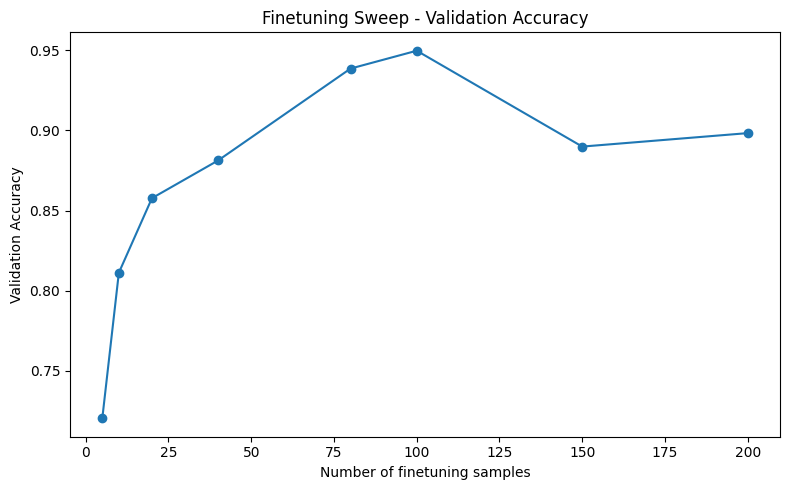

Saved plot to: ./logger_finetuning/finetune_sweep_val_acc.png


In [238]:
# ============================================
# Cell FT22: plot sweep
# ============================================
_ = plot_finetune_sweep(
    sweep_df,
    logger_root=FINETUNE_LOGGER_ROOT,
    title="Finetuning Sweep - Validation Accuracy",
)

Add new fuunction

In [229]:
# ============================================
# Cell AF1: add-function config
# ============================================
ADD_FUNCTION_DATA_ROOT = DATA_ROOT   # dataset root that now includes "sit"
PREVIOUS_RUN_DIR_FOR_EXPANSION = PRETRAINED_RUN_DIR if "PRETRAINED_RUN_DIR" in globals() else None

NEW_CLASS_NAME = "sit"

# How many training samples of the new class to use.
# None = use all available new-class training samples
NEW_CLASS_TRAIN_SAMPLES = 1

# "expand_from_checkpoint" or "scratch"
ADD_FUNCTION_INIT_MODE = "expand_from_checkpoint"

# Logger
ADD_FUNCTION_LOGGER_ROOT = "./logger_add_function"
ADD_FUNCTION_RUN_NOTE = "add_new_class"

# Split
ADD_FUNCTION_TRAIN_RATIO = 0.7
ADD_FUNCTION_VAL_RATIO = 0.15
ADD_FUNCTION_TEST_RATIO = 0.15
ADD_FUNCTION_RANDOM_SEED = 42
ADD_FUNCTION_STRATIFY = True

# Training
ADD_FUNCTION_BATCH_SIZE = BATCH_SIZE
ADD_FUNCTION_NUM_WORKERS = NUM_WORKERS
ADD_FUNCTION_EPOCHS = 400
ADD_FUNCTION_LEARNING_RATE = 1e-4
ADD_FUNCTION_WEIGHT_DECAY = 1e-4
ADD_FUNCTION_USE_CLASS_WEIGHTS = True
ADD_FUNCTION_USE_LR_SCHEDULER = True

# Early stopping
ADD_FUNCTION_EARLY_STOPPING_PATIENCE = 10
ADD_FUNCTION_EARLY_STOPPING_MIN_DELTA = 1e-4

os.makedirs(ADD_FUNCTION_LOGGER_ROOT, exist_ok=True)

In [230]:
# ============================================
# Cell AF2: folder and label helpers
# ============================================
def detect_class_folders(data_root):
    class_names = []
    for name in os.listdir(data_root):
        full_path = os.path.join(data_root, name)
        if os.path.isdir(full_path):
            class_names.append(name)
    return sorted(class_names)


def build_labels_with_new_class(data_root, new_class_name, previous_cfg=None):
    detected = detect_class_folders(data_root)

    if previous_cfg is not None:
        old_labels = list(previous_cfg["data"]["LABELS"])
    else:
        old_labels = [x for x in detected if x != new_class_name]

    if new_class_name not in detected:
        raise ValueError(f"New class folder '{new_class_name}' not found in {data_root}")

    labels = []
    for x in old_labels:
        if x in detected:
            labels.append(x)

    for x in detected:
        if x not in labels:
            labels.append(x)

    if new_class_name not in labels:
        labels.append(new_class_name)

    return labels

In [231]:
# ============================================
# Cell AF3: split helpers with new-class train cap
# ============================================
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split


def make_train_val_test_subsets_for_new_class(
    dataset,
    labels,
    new_class_name,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
    stratify=True,
    new_class_train_samples=None,
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8

    indices = list(range(len(dataset)))
    y = [dataset.samples[i]["label_idx"] for i in indices]
    stratify_y = y if stratify else None

    train_indices, temp_indices = train_test_split(
        indices,
        test_size=(1.0 - train_ratio),
        random_state=random_seed,
        stratify=stratify_y,
    )

    temp_y = [dataset.samples[i]["label_idx"] for i in temp_indices]
    temp_stratify_y = temp_y if stratify else None

    val_portion_of_temp = val_ratio / (val_ratio + test_ratio)

    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=(1.0 - val_portion_of_temp),
        random_state=random_seed,
        stratify=temp_stratify_y,
    )

    if new_class_train_samples is not None:
        label_to_idx = {name: i for i, name in enumerate(labels)}
        new_class_idx = label_to_idx[new_class_name]

        new_class_train_idx = [i for i in train_indices if dataset.samples[i]["label_idx"] == new_class_idx]
        other_train_idx = [i for i in train_indices if dataset.samples[i]["label_idx"] != new_class_idx]

        if len(new_class_train_idx) == 0:
            raise ValueError(f"No training samples found for new class '{new_class_name}'")

        rng = np.random.RandomState(random_seed)
        rng.shuffle(new_class_train_idx)

        kept_new_class_train_idx = new_class_train_idx[:new_class_train_samples]
        train_indices = other_train_idx + kept_new_class_train_idx
        rng.shuffle(train_indices)

    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    test_subset = Subset(dataset, test_indices)
    
    return train_subset, val_subset, test_subset, train_indices, val_indices, test_indices


def summarize_subset_generic(subset, base_dataset, labels, name="subset"):
    counts = {}
    for idx in subset.indices:
        label_name = base_dataset.samples[idx]["label_name"]
        counts[label_name] = counts.get(label_name, 0) + 1

    print(f"{name}: {len(subset)} samples")
    for label in labels:
        print(f"  {label}: {counts.get(label, 0)}")

In [232]:
# ============================================
# Cell AF4: model build helpers
# ============================================
def build_model_from_config_with_num_classes(cfg, num_classes):
    model_type = cfg["model"]["MODEL_TYPE"]
    body_landmarks_used = cfg["data"]["BODY_LANDMARK_USED"]
    num_body_landmarks_used = 17 if body_landmarks_used is None else len(body_landmarks_used)

    common_kwargs = dict(
        num_classes=num_classes,
        video_input_enabled=cfg["data"]["VIDEO_INPUT_ENABLED"],
        body_pose_input_enabled=cfg["data"]["BODY_POSE_INPUT_ENABLED"],
        hand_pose_input_enabled=cfg["data"]["HAND_POSE_INPUT_ENABLED"],
        num_body_landmarks=num_body_landmarks_used,
        video_feature_dim=cfg["model"]["VIDEO_FEATURE_DIM"],
        use_body_mlp=cfg["model"]["USE_BODY_MLP"],
        body_feature_dim=cfg["model"]["BODY_FEATURE_DIM"],
        use_hand_mlp=cfg["model"]["USE_HAND_MLP"],
        hand_feature_dim=cfg["model"]["HAND_FEATURE_DIM"],
        classifier_hidden_dim=cfg["model"]["CLASSIFIER_HIDDEN_DIM"],
        classifier_dropout=cfg["model"]["DROPOUT"],
    )

    if model_type == "LSTM":
        model = GestureLSTMClassifier(
            **common_kwargs,
            hidden_dim=cfg["model"]["LSTM_HIDDEN_DIM"],
            num_layers=cfg["model"]["LSTM_NUM_LAYERS"],
            dropout=cfg["model"]["LSTM_DROPOUT"],
            bidirectional=cfg["model"]["LSTM_BIDIRECTIONAL"],
        )
    elif model_type == "CNN":
        model = GestureCNNClassifier(
            **common_kwargs,
            hidden_dim=cfg["model"]["CNN_HIDDEN_DIM"],
            dropout=cfg["model"]["CNN_DROPOUT"],
        )
    else:
        raise ValueError(f"Unsupported MODEL_TYPE: {model_type}")

    return model


def replace_last_classifier_layer(model, new_num_classes):
    if not hasattr(model, "classifier"):
        raise ValueError("Model has no .classifier module")

    if not isinstance(model.classifier, nn.Sequential):
        raise ValueError("Expected model.classifier to be nn.Sequential")

    old_last = model.classifier[-1]
    if not isinstance(old_last, nn.Linear):
        raise ValueError("Expected last classifier layer to be nn.Linear")

    in_features = old_last.in_features
    new_last = nn.Linear(in_features, new_num_classes)

    with torch.no_grad():
        old_out = old_last.out_features
        keep = min(old_out, new_num_classes)
        new_last.weight[:keep].copy_(old_last.weight[:keep])
        new_last.bias[:keep].copy_(old_last.bias[:keep])

        if new_num_classes > old_out:
            nn.init.xavier_uniform_(new_last.weight[old_out:])
            nn.init.zeros_(new_last.bias[old_out:])

    model.classifier[-1] = new_last
    return model

In [233]:
# ============================================
# Cell AF5: previous run loader for expansion
# ============================================
def load_previous_run_for_expansion(run_dir):
    if run_dir is None:
        raise ValueError("PREVIOUS_RUN_DIR_FOR_EXPANSION is None")

    config_path = os.path.join(run_dir, "config.json")
    checkpoint_path = os.path.join(run_dir, "best_model.pt")

    if not os.path.isfile(config_path):
        raise FileNotFoundError(f"config.json not found in: {run_dir}")
    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"best_model.pt not found in: {run_dir}")

    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    return cfg, checkpoint_path

In [234]:
# ============================================
# Cell AF6: add-function logger helpers
# ============================================
def build_add_function_run_config(
    model,
    labels,
    data_root,
    new_class_name,
    new_class_train_samples,
    init_mode,
    previous_run_dir,
    previous_checkpoint_path,
    previous_cfg,
):
    total_params, trainable_params = count_parameters(model)

    cfg = {
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "run_note": ADD_FUNCTION_RUN_NOTE,
            "run_type": "add_function",
        },
        "data": {
            "DATA_ROOT": data_root,
            "LABELS": labels,
            "NUM_CLASSES": len(labels),
            "NEW_CLASS_NAME": new_class_name,
            "NEW_CLASS_TRAIN_SAMPLES": new_class_train_samples,
            "VIDEO_INPUT_ENABLED": VIDEO_INPUT_ENABLED if previous_cfg is None else previous_cfg["data"]["VIDEO_INPUT_ENABLED"],
            "BODY_POSE_INPUT_ENABLED": BODY_POSE_INPUT_ENABLED if previous_cfg is None else previous_cfg["data"]["BODY_POSE_INPUT_ENABLED"],
            "HAND_POSE_INPUT_ENABLED": HAND_POSE_INPUT_ENABLED if previous_cfg is None else previous_cfg["data"]["HAND_POSE_INPUT_ENABLED"],
            "BODY_LANDMARK_USED": BODY_LANDMARK_USED if previous_cfg is None else previous_cfg["data"]["BODY_LANDMARK_USED"],
            "VIDEO_SIZE": VIDEO_SIZE if previous_cfg is None else previous_cfg["data"]["VIDEO_SIZE"],
            "VIDEO_NORMALIZE": VIDEO_NORMALIZE if previous_cfg is None else previous_cfg["data"]["VIDEO_NORMALIZE"],
            "VIDEO_PAD_LENGTH": VIDEO_PAD_LENGTH if previous_cfg is None else previous_cfg["data"]["VIDEO_PAD_LENGTH"],
            "BODY_PAD_LENGTH": BODY_PAD_LENGTH if previous_cfg is None else previous_cfg["data"]["BODY_PAD_LENGTH"],
            "HAND_PAD_LENGTH": HAND_PAD_LENGTH if previous_cfg is None else previous_cfg["data"]["HAND_PAD_LENGTH"],
        },
        "training": {
            "INIT_MODE": init_mode,
            "PREVIOUS_RUN_DIR": previous_run_dir,
            "PREVIOUS_CHECKPOINT_PATH": previous_checkpoint_path,
            "TRAIN_RATIO": ADD_FUNCTION_TRAIN_RATIO,
            "VAL_RATIO": ADD_FUNCTION_VAL_RATIO,
            "TEST_RATIO": ADD_FUNCTION_TEST_RATIO,
            "RANDOM_SEED": ADD_FUNCTION_RANDOM_SEED,
            "STRATIFY": ADD_FUNCTION_STRATIFY,
            "BATCH_SIZE": ADD_FUNCTION_BATCH_SIZE,
            "NUM_WORKERS": ADD_FUNCTION_NUM_WORKERS,
            "EPOCHS": ADD_FUNCTION_EPOCHS,
            "LEARNING_RATE": ADD_FUNCTION_LEARNING_RATE,
            "WEIGHT_DECAY": ADD_FUNCTION_WEIGHT_DECAY,
            "USE_CLASS_WEIGHTS": ADD_FUNCTION_USE_CLASS_WEIGHTS,
            "USE_LR_SCHEDULER": ADD_FUNCTION_USE_LR_SCHEDULER,
            "EARLY_STOPPING_PATIENCE": ADD_FUNCTION_EARLY_STOPPING_PATIENCE,
            "EARLY_STOPPING_MIN_DELTA": ADD_FUNCTION_EARLY_STOPPING_MIN_DELTA,
            "DEVICE": str(DEVICE),
        },
        "model": {
            "model_structure": str(model),
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
        },
    }
    return safe_to_python(cfg)

In [235]:
# ============================================
# Cell AF7: add_function main pipeline
# ============================================
def add_function(
    data_root,
    new_class_name="sit",
    new_class_train_samples=None,
    init_mode="expand_from_checkpoint",
    previous_run_dir=None,
    logger_root="./logger_add_function",
    run_note="add_new_class",
):
    os.makedirs(logger_root, exist_ok=True)

    # ----------------------------------------
    # Load previous config if needed
    # ----------------------------------------
    previous_cfg = None
    previous_checkpoint_path = None

    if init_mode == "expand_from_checkpoint":
        previous_cfg, previous_checkpoint_path = load_previous_run_for_expansion(previous_run_dir)
        labels = build_labels_with_new_class(data_root, new_class_name, previous_cfg=previous_cfg)
    elif init_mode == "scratch":
        labels = build_labels_with_new_class(data_root, new_class_name, previous_cfg=None)
    else:
        raise ValueError("init_mode must be 'expand_from_checkpoint' or 'scratch'")

    print("Detected labels:", labels)

    # ----------------------------------------
    # Determine dataset settings
    # ----------------------------------------
    if previous_cfg is not None:
        used_video_input_enabled = previous_cfg["data"]["VIDEO_INPUT_ENABLED"]
        used_body_pose_input_enabled = previous_cfg["data"]["BODY_POSE_INPUT_ENABLED"]
        used_hand_pose_input_enabled = previous_cfg["data"]["HAND_POSE_INPUT_ENABLED"]
        used_body_landmark_used = previous_cfg["data"]["BODY_LANDMARK_USED"]
        used_video_size = tuple(previous_cfg["data"]["VIDEO_SIZE"])
        used_video_normalize = previous_cfg["data"]["VIDEO_NORMALIZE"]
        used_video_pad_length = previous_cfg["data"]["VIDEO_PAD_LENGTH"]
        used_body_pad_length = previous_cfg["data"]["BODY_PAD_LENGTH"]
        used_hand_pad_length = previous_cfg["data"]["HAND_PAD_LENGTH"]
        used_require_all_three = previous_cfg["data"]["REQUIRE_ALL_THREE_COMPONENTS"]
        used_truncate_if_longer = previous_cfg["data"]["TRUNCATE_IF_LONGER"]
    else:
        used_video_input_enabled = VIDEO_INPUT_ENABLED
        used_body_pose_input_enabled = BODY_POSE_INPUT_ENABLED
        used_hand_pose_input_enabled = HAND_POSE_INPUT_ENABLED
        used_body_landmark_used = BODY_LANDMARK_USED
        used_video_size = VIDEO_SIZE
        used_video_normalize = VIDEO_NORMALIZE
        used_video_pad_length = VIDEO_PAD_LENGTH
        used_body_pad_length = BODY_PAD_LENGTH
        used_hand_pad_length = HAND_PAD_LENGTH
        used_require_all_three = REQUIRE_ALL_THREE_COMPONENTS
        used_truncate_if_longer = TRUNCATE_IF_LONGER

    # This dataset class uses global TRUNCATE_IF_LONGER
    globals()["TRUNCATE_IF_LONGER"] = used_truncate_if_longer

    # ----------------------------------------
    # Build dataset
    # ----------------------------------------
    add_dataset = GestureEpisodeDataset(
        data_root=data_root,
        labels=labels,
        video_input_enabled=used_video_input_enabled,
        body_pose_input_enabled=used_body_pose_input_enabled,
        hand_pose_input_enabled=used_hand_pose_input_enabled,
        body_landmark_used=used_body_landmark_used,
        video_size=used_video_size,
        video_normalize=used_video_normalize,
        video_pad_length=used_video_pad_length,
        body_pad_length=used_body_pad_length,
        hand_pad_length=used_hand_pad_length,
        require_all_three_components=used_require_all_three,
        verbose_screening=True,
    )

    print("Full dataset size:", len(add_dataset))

    # ----------------------------------------
    # Split
    # ----------------------------------------
    train_dataset, val_dataset, test_dataset, train_idx, val_idx, test_idx = make_train_val_test_subsets_for_new_class(
        dataset=add_dataset,
        labels=labels,
        new_class_name=new_class_name,
        train_ratio=ADD_FUNCTION_TRAIN_RATIO,
        val_ratio=ADD_FUNCTION_VAL_RATIO,
        test_ratio=ADD_FUNCTION_TEST_RATIO,
        random_seed=ADD_FUNCTION_RANDOM_SEED,
        stratify=ADD_FUNCTION_STRATIFY,
        new_class_train_samples=new_class_train_samples,
    )

    summarize_subset_generic(train_dataset, add_dataset, labels, "train")
    summarize_subset_generic(val_dataset, add_dataset, labels, "val")
    summarize_subset_generic(test_dataset, add_dataset, labels, "test")

    # ----------------------------------------
    # Loaders
    # ----------------------------------------
    train_loader_local = DataLoader(
        train_dataset,
        batch_size=ADD_FUNCTION_BATCH_SIZE,
        shuffle=True,
        num_workers=ADD_FUNCTION_NUM_WORKERS,
        collate_fn=gesture_collate_fn_stacked,
    )

    val_loader_local = DataLoader(
        val_dataset,
        batch_size=ADD_FUNCTION_BATCH_SIZE,
        shuffle=False,
        num_workers=ADD_FUNCTION_NUM_WORKERS,
        collate_fn=gesture_collate_fn_stacked,
    )

    test_loader_local = DataLoader(
        test_dataset,
        batch_size=ADD_FUNCTION_BATCH_SIZE,
        shuffle=False,
        num_workers=ADD_FUNCTION_NUM_WORKERS,
        collate_fn=gesture_collate_fn_stacked,
    )

    # ----------------------------------------
    # Build model
    # ----------------------------------------
    if init_mode == "expand_from_checkpoint":
        # Step 1: build old model with old num classes
        old_num_classes = previous_cfg["data"]["NUM_CLASSES"]
        model = build_model_from_config_with_num_classes(previous_cfg, old_num_classes)
        model.load_state_dict(torch.load(previous_checkpoint_path, map_location=DEVICE))

        # Step 2: expand final layer to new num classes
        model = replace_last_classifier_layer(model, len(labels))

    else:
        # scratch
        if previous_cfg is not None:
            model = build_model_from_config_with_num_classes(previous_cfg, len(labels))
        else:
            # build from current notebook config
            body_landmarks_used = used_body_landmark_used
            num_body_landmarks_used = 17 if body_landmarks_used is None else len(body_landmarks_used)

            if MODEL_TYPE == "LSTM":
                model = GestureLSTMClassifier(
                    num_classes=len(labels),
                    video_input_enabled=used_video_input_enabled,
                    body_pose_input_enabled=used_body_pose_input_enabled,
                    hand_pose_input_enabled=used_hand_pose_input_enabled,
                    num_body_landmarks=num_body_landmarks_used,
                    video_feature_dim=VIDEO_FEATURE_DIM,
                    use_body_mlp=USE_BODY_MLP,
                    body_feature_dim=BODY_FEATURE_DIM,
                    use_hand_mlp=USE_HAND_MLP,
                    hand_feature_dim=HAND_FEATURE_DIM,
                    hidden_dim=LSTM_HIDDEN_DIM,
                    num_layers=LSTM_NUM_LAYERS,
                    dropout=LSTM_DROPOUT,
                    bidirectional=LSTM_BIDIRECTIONAL,
                    classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
                    classifier_dropout=DROPOUT,
                )
            elif MODEL_TYPE == "CNN":
                model = GestureCNNClassifier(
                    num_classes=len(labels),
                    video_input_enabled=used_video_input_enabled,
                    body_pose_input_enabled=used_body_pose_input_enabled,
                    hand_pose_input_enabled=used_hand_pose_input_enabled,
                    num_body_landmarks=num_body_landmarks_used,
                    video_feature_dim=VIDEO_FEATURE_DIM,
                    use_body_mlp=USE_BODY_MLP,
                    body_feature_dim=BODY_FEATURE_DIM,
                    use_hand_mlp=USE_HAND_MLP,
                    hand_feature_dim=HAND_FEATURE_DIM,
                    hidden_dim=CNN_HIDDEN_DIM,
                    dropout=CNN_DROPOUT,
                    classifier_hidden_dim=CLASSIFIER_HIDDEN_DIM,
                    classifier_dropout=DROPOUT,
                )
            else:
                raise ValueError("MODEL_TYPE must be 'LSTM' or 'CNN'")

    model = model.to(DEVICE)
    print(model)

    # ----------------------------------------
    # Loss and optimizer
    # ----------------------------------------
    if ADD_FUNCTION_USE_CLASS_WEIGHTS:
        class_weights = compute_class_weights_from_subset_base(
            train_dataset,
            add_dataset,
            len(labels),
        ).to(DEVICE)
    else:
        class_weights = None

    criterion_local = nn.CrossEntropyLoss(weight=class_weights)

    optimizer_local = torch.optim.Adam(
        model.parameters(),
        lr=ADD_FUNCTION_LEARNING_RATE,
        weight_decay=ADD_FUNCTION_WEIGHT_DECAY,
    )

    if ADD_FUNCTION_USE_LR_SCHEDULER:
        scheduler_local = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_local,
            mode="min",
            factor=0.5,
            patience=3,
        )
    else:
        scheduler_local = None

    # ----------------------------------------
    # Run dir and checkpoint path
    # ----------------------------------------
    model_tag = previous_cfg["model"]["MODEL_TYPE"] if previous_cfg is not None else MODEL_TYPE
    run_name, run_dir = make_run_dir(
        logger_root=logger_root,
        model_type=f"ADDCLS_{model_tag}",
        lr=ADD_FUNCTION_LEARNING_RATE,
        epochs=ADD_FUNCTION_EPOCHS,
        video_enabled=used_video_input_enabled,
        body_enabled=used_body_pose_input_enabled,
        hand_enabled=used_hand_pose_input_enabled,
        note=f"{run_note}__new_{new_class_name}__n_{new_class_train_samples}",
    )

    best_model_path = os.path.join(run_dir, "best_model.pt")

    # ----------------------------------------
    # Training loop with early stopping
    # ----------------------------------------
    history_local = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = -1
    best_state_dict = copy.deepcopy(model.state_dict())

    epochs_without_improvement = 0
    early_stopped = False
    early_stop_reason = ""

    for epoch in range(ADD_FUNCTION_EPOCHS):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model=model,
            loader=train_loader_local,
            optimizer=optimizer_local,
            criterion=criterion_local,
            device=DEVICE,
            train=True,
        )

        val_metrics = run_one_epoch(
            model=model,
            loader=val_loader_local,
            optimizer=optimizer_local,
            criterion=criterion_local,
            device=DEVICE,
            train=False,
        )

        if scheduler_local is not None:
            scheduler_local.step(val_metrics["loss"])

        history_local["train_loss"].append(train_metrics["loss"])
        history_local["train_acc"].append(train_metrics["acc"])
        history_local["val_loss"].append(val_metrics["loss"])
        history_local["val_acc"].append(val_metrics["acc"])

        epoch_time = time.time() - start_time

        print(
            f"Epoch [{epoch+1}/{ADD_FUNCTION_EPOCHS}] | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train Acc: {train_metrics['acc']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['acc']:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        improvement = best_val_loss - val_metrics["loss"]

        if improvement > ADD_FUNCTION_EARLY_STOPPING_MIN_DELTA:
            best_val_loss = val_metrics["loss"]
            best_val_acc = val_metrics["acc"]
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())
            torch.save(best_state_dict, best_model_path)
            epochs_without_improvement = 0
            print("  Saved best checkpoint:", best_model_path)
        else:
            epochs_without_improvement += 1
            print(
                f"  No significant val loss improvement. "
                f"Counter: {epochs_without_improvement}/{ADD_FUNCTION_EARLY_STOPPING_PATIENCE}"
            )

        if epochs_without_improvement >= ADD_FUNCTION_EARLY_STOPPING_PATIENCE:
            early_stopped = True
            early_stop_reason = (
                f"No val loss improvement > {ADD_FUNCTION_EARLY_STOPPING_MIN_DELTA} "
                f"for {ADD_FUNCTION_EARLY_STOPPING_PATIENCE} consecutive epochs."
            )
            print("Early stopping triggered.")
            break

    # ----------------------------------------
    # Load best model
    # ----------------------------------------
    if os.path.isfile(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    # ----------------------------------------
    # Final evaluation
    # ----------------------------------------
    train_metrics_logged = evaluate_loader_with_ids(model, train_loader_local, criterion_local, DEVICE)
    val_metrics_logged = evaluate_loader_with_ids(model, val_loader_local, criterion_local, DEVICE)
    test_metrics_logged = evaluate_loader_with_ids(model, test_loader_local, criterion_local, DEVICE)

    print("Final train acc:", round(train_metrics_logged["acc"], 4))
    print("Final val acc  :", round(val_metrics_logged["acc"], 4))
    print("Final test acc :", round(test_metrics_logged["acc"], 4))

    # ----------------------------------------
    # Logging
    # ----------------------------------------
    config = build_add_function_run_config(
        model=model,
        labels=labels,
        data_root=data_root,
        new_class_name=new_class_name,
        new_class_train_samples=new_class_train_samples,
        init_mode=init_mode,
        previous_run_dir=previous_run_dir,
        previous_checkpoint_path=previous_checkpoint_path,
        previous_cfg=previous_cfg,
    )

    config["early_stopping_result"] = {
        "early_stopped": early_stopped,
        "early_stop_reason": early_stop_reason,
        "best_epoch": best_epoch,
        "best_val_loss": None if best_epoch == -1 else float(best_val_loss),
        "best_val_acc": None if best_epoch == -1 else float(best_val_acc),
    }

    config["paths"] = {
        "run_dir": run_dir,
        "best_model_path": best_model_path,
    }

    save_json(os.path.join(run_dir, "config.json"), config)
    save_text(os.path.join(run_dir, "model_structure.txt"), str(model))
    save_history_csv(os.path.join(run_dir, "history.csv"), history_local)

    title_prefix = (
        f"ADDCLS-{model_tag} | lr={ADD_FUNCTION_LEARNING_RATE} | "
        f"ep={ADD_FUNCTION_EPOCHS} | new={new_class_name} | "
        f"n={new_class_train_samples}"
    )

    loss_plot_path, acc_plot_path = plot_and_save_training_curves(history_local, run_dir, title_prefix)

    y_true = test_metrics_logged["labels"]
    y_pred = test_metrics_logged["preds"]
    session_ids = test_metrics_logged["session_ids"]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))))
    cm_path = save_confusion_matrix_plot(cm, labels, run_dir, title_prefix)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=labels,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    save_json(os.path.join(run_dir, "classification_report.json"), report_dict)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result_metrics = {
        "run_name": run_name,
        "new_class_name": new_class_name,
        "new_class_train_samples": new_class_train_samples,
        "init_mode": init_mode,
        "train_loss_last": float(history_local["train_loss"][-1]),
        "train_acc_last": float(history_local["train_acc"][-1]),
        "val_loss_last": float(history_local["val_loss"][-1]),
        "val_acc_last": float(history_local["val_acc"][-1]),
        "test_loss": float(test_metrics_logged["loss"]),
        "test_acc": float(test_metrics_logged["acc"]),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
        "early_stopped": early_stopped,
        "best_epoch": best_epoch,
    }

    save_json(os.path.join(run_dir, "result_metrics.json"), result_metrics)
    save_metrics_csv(os.path.join(run_dir, "result_metrics.csv"), result_metrics)

    save_predictions_csv(
        os.path.join(run_dir, "test_predictions.csv"),
        y_true=y_true,
        y_pred=y_pred,
        label_names=labels,
        session_ids=session_ids,
    )

    save_json(os.path.join(run_dir, "train_metrics.json"), train_metrics_logged)
    save_json(os.path.join(run_dir, "val_metrics.json"), val_metrics_logged)
    save_json(os.path.join(run_dir, "test_metrics_full.json"), test_metrics_logged)

    meta_row = {
        "run_name": run_name,
        "run_dir": run_dir,
        "checkpoint_path": best_model_path,
        "loss_plot_path": loss_plot_path,
        "acc_plot_path": acc_plot_path,
        "cm_plot_path": cm_path,
        **result_metrics,
        **flatten_dict(config),
    }

    meta_csv_path = os.path.join(logger_root, "meta_runs_add_function.csv")
    append_meta_csv(meta_csv_path, meta_row)

    print("Run logged to:", run_dir)
    print("Meta CSV updated:", meta_csv_path)

    return {
        "model": model,
        "labels": labels,
        "dataset": add_dataset,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader_local,
        "val_loader": val_loader_local,
        "test_loader": test_loader_local,
        "history": history_local,
        "train_metrics": train_metrics_logged,
        "val_metrics": val_metrics_logged,
        "test_metrics": test_metrics_logged,
        "run_dir": run_dir,
        "best_model_path": best_model_path,
        "meta_csv_path": meta_csv_path,
    }

UNcomment following to run

In [236]:
# ============================================
# Cell AF8: execute add_function
# ============================================
#add_function_result = add_function(
#    data_root=ADD_FUNCTION_DATA_ROOT,
#    new_class_name=NEW_CLASS_NAME,
#    new_class_train_samples=NEW_CLASS_TRAIN_SAMPLES,
#    init_mode=ADD_FUNCTION_INIT_MODE,
#    previous_run_dir=PREVIOUS_RUN_DIR_FOR_EXPANSION,
#    logger_root=ADD_FUNCTION_LOGGER_ROOT,
#    run_note=ADD_FUNCTION_RUN_NOTE,
#)
#
#add_function_result["test_metrics"]["acc"]

In [237]:
# ============================================
# Cell AF9: sweep over new-class sample counts
# ============================================
NEW_CLASS_TRAIN_SAMPLE_SWEEP = [5, 10, 20, 40, 50,60,70,80,90,100,None]

sweep_results = []

#for n in NEW_CLASS_TRAIN_SAMPLE_SWEEP:
#    print("\n" + "=" * 80)
#    print("Running add_function with NEW_CLASS_TRAIN_SAMPLES =", n)
#    print("=" * 80)
#
#    result = add_function(
#        data_root=ADD_FUNCTION_DATA_ROOT,
#        new_class_name=NEW_CLASS_NAME,
#        new_class_train_samples=n,
#        init_mode=ADD_FUNCTION_INIT_MODE,
#        previous_run_dir=PREVIOUS_RUN_DIR_FOR_EXPANSION,
#        logger_root=ADD_FUNCTION_LOGGER_ROOT,
#        run_note=f"{ADD_FUNCTION_RUN_NOTE}_sweep",
#    )
#
#    sweep_results.append({
#        "new_class_train_samples": n,
#        "val_acc": result["val_metrics"]["acc"],
#        "test_acc": result["test_metrics"]["acc"],
#        "run_dir": result["run_dir"],
#    })

#sweep_df = pd.DataFrame(sweep_results)
#display(sweep_df)